In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
df = pd.read_csv("../data/processed/campaign_data_cleaned.csv")

# Convert date column back to datetime
df["start_date"] = pd.to_datetime(
    df["start_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (10000, 40)


In [16]:
print("\nData Types:")
display(df.dtypes)


Data Types:


campaign_id                                str
campaign_objective                         str
platform                                   str
ad_placement                               str
device_type                                str
operating_system                           str
creative_format                            str
creative_size                              str
ad_copy_length                             str
has_call_to_action                        bool
creative_emotion                           str
creative_age_days                        int64
target_audience_age                        str
target_audience_gender                     str
audience_interest_category                 str
income_bracket                             str
purchase_intent_score                      str
retargeting_flag                          bool
start_date                      datetime64[us]
quarter                                  int64
day_of_week                                str
hour_of_day  

In [17]:
display(df.head())

print("\nNumerical Variables:", len(df.select_dtypes(include=np.number).columns))
print("Categorical Variables:", len(df.select_dtypes(include=["object", "string"]).columns))

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.606,2.23,0.498,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,50094,467,5,1158.16,1728.20,63.73,105,2.74,Finance,Medium,0.932,2.48,1.071,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,10842,112,6,434.56,2903.26,31.93,149,3.97,Healthcare,Low,1.033,3.88,5.357,72.43,6.68,2468.70
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,7820,123,3,1019.67,502.28,65.52,147,2.49,Education,Medium,1.573,8.29,2.439,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.409,1.41,0.000,0.00,0.00,-425.82



Numerical Variables: 19
Categorical Variables: 18


start_date is now a datetime variable, so it is not counted as categorical.
has_call_to_action and retargeting_flag are boolean variables, so they are not included in either the numerical or categorical count.

## 3.3 Numerical Variable Analysis

This section examines the distribution and statistical characteristics of the numerical variables in the dataset.

The analysis includes:

- Descriptive statistics
- Distribution of key campaign performance metrics
- Identification of skewness
- Detection of potential outliers

Special attention is given to important campaign KPIs such as impressions, clicks, conversions, ad spend, revenue, CTR, conversion rate, ROAS, and profit.

In [18]:
numerical_columns = df.select_dtypes(include=np.number).columns

display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
creative_age_days,10000.0,45.374300,26.171100,1.00,22.0000,45.0000,68.00000,90.00
quarter,10000.0,2.419100,1.132424,1.00,1.0000,2.0000,3.00000,4.00
hour_of_day,10000.0,11.482500,6.932308,0.00,5.0000,12.0000,18.00000,23.00
campaign_day,10000.0,45.429700,26.071107,1.00,23.0000,45.0000,68.00000,90.00
quality_score,10000.0,5.527400,1.553541,1.00,4.0000,6.0000,7.00000,10.00
impressions,10000.0,70539.223000,91339.733246,5000.00,16958.5000,37469.5000,83213.75000,500000.00
clicks,10000.0,1526.436100,2412.164582,10.00,290.0000,718.0000,1746.00000,40000.00
conversions,10000.0,65.568800,183.404876,0.00,5.0000,16.0000,55.00000,5384.00
ad_spend,10000.0,4345.566179,6917.481037,8.69,666.3075,1895.6700,4996.16000,49999.68
revenue,10000.0,28415.770647,89284.609131,0.00,1608.9100,6099.2400,22165.82500,2800397.43


In [19]:
skewness = df[numerical_columns].skew().sort_values(
    ascending=False
)

display(skewness.to_frame(name="Skewness"))

,Skewness
profit,13.031009
revenue,12.551164
conversions,11.732935
ROAS,9.345862
CPA,5.745063
clicks,4.693409
ad_spend,3.589109
impressions,2.713216
conversion_rate,2.555492
CTR,1.438125


* Visual Distribution Analysis 

# Distribution of Key Campaign Performance Metrics

The descriptive statistics and skewness analysis indicate that several campaign performance variables are strongly right-skewed.

The following visualizations examine the distributions of key campaign metrics:

- Impressions
- Clicks
- Conversions
- Ad Spend
- Revenue
- CTR
- Conversion Rate
- ROAS
- Profit

These plots help identify distribution patterns, extreme values, and potential outliers.

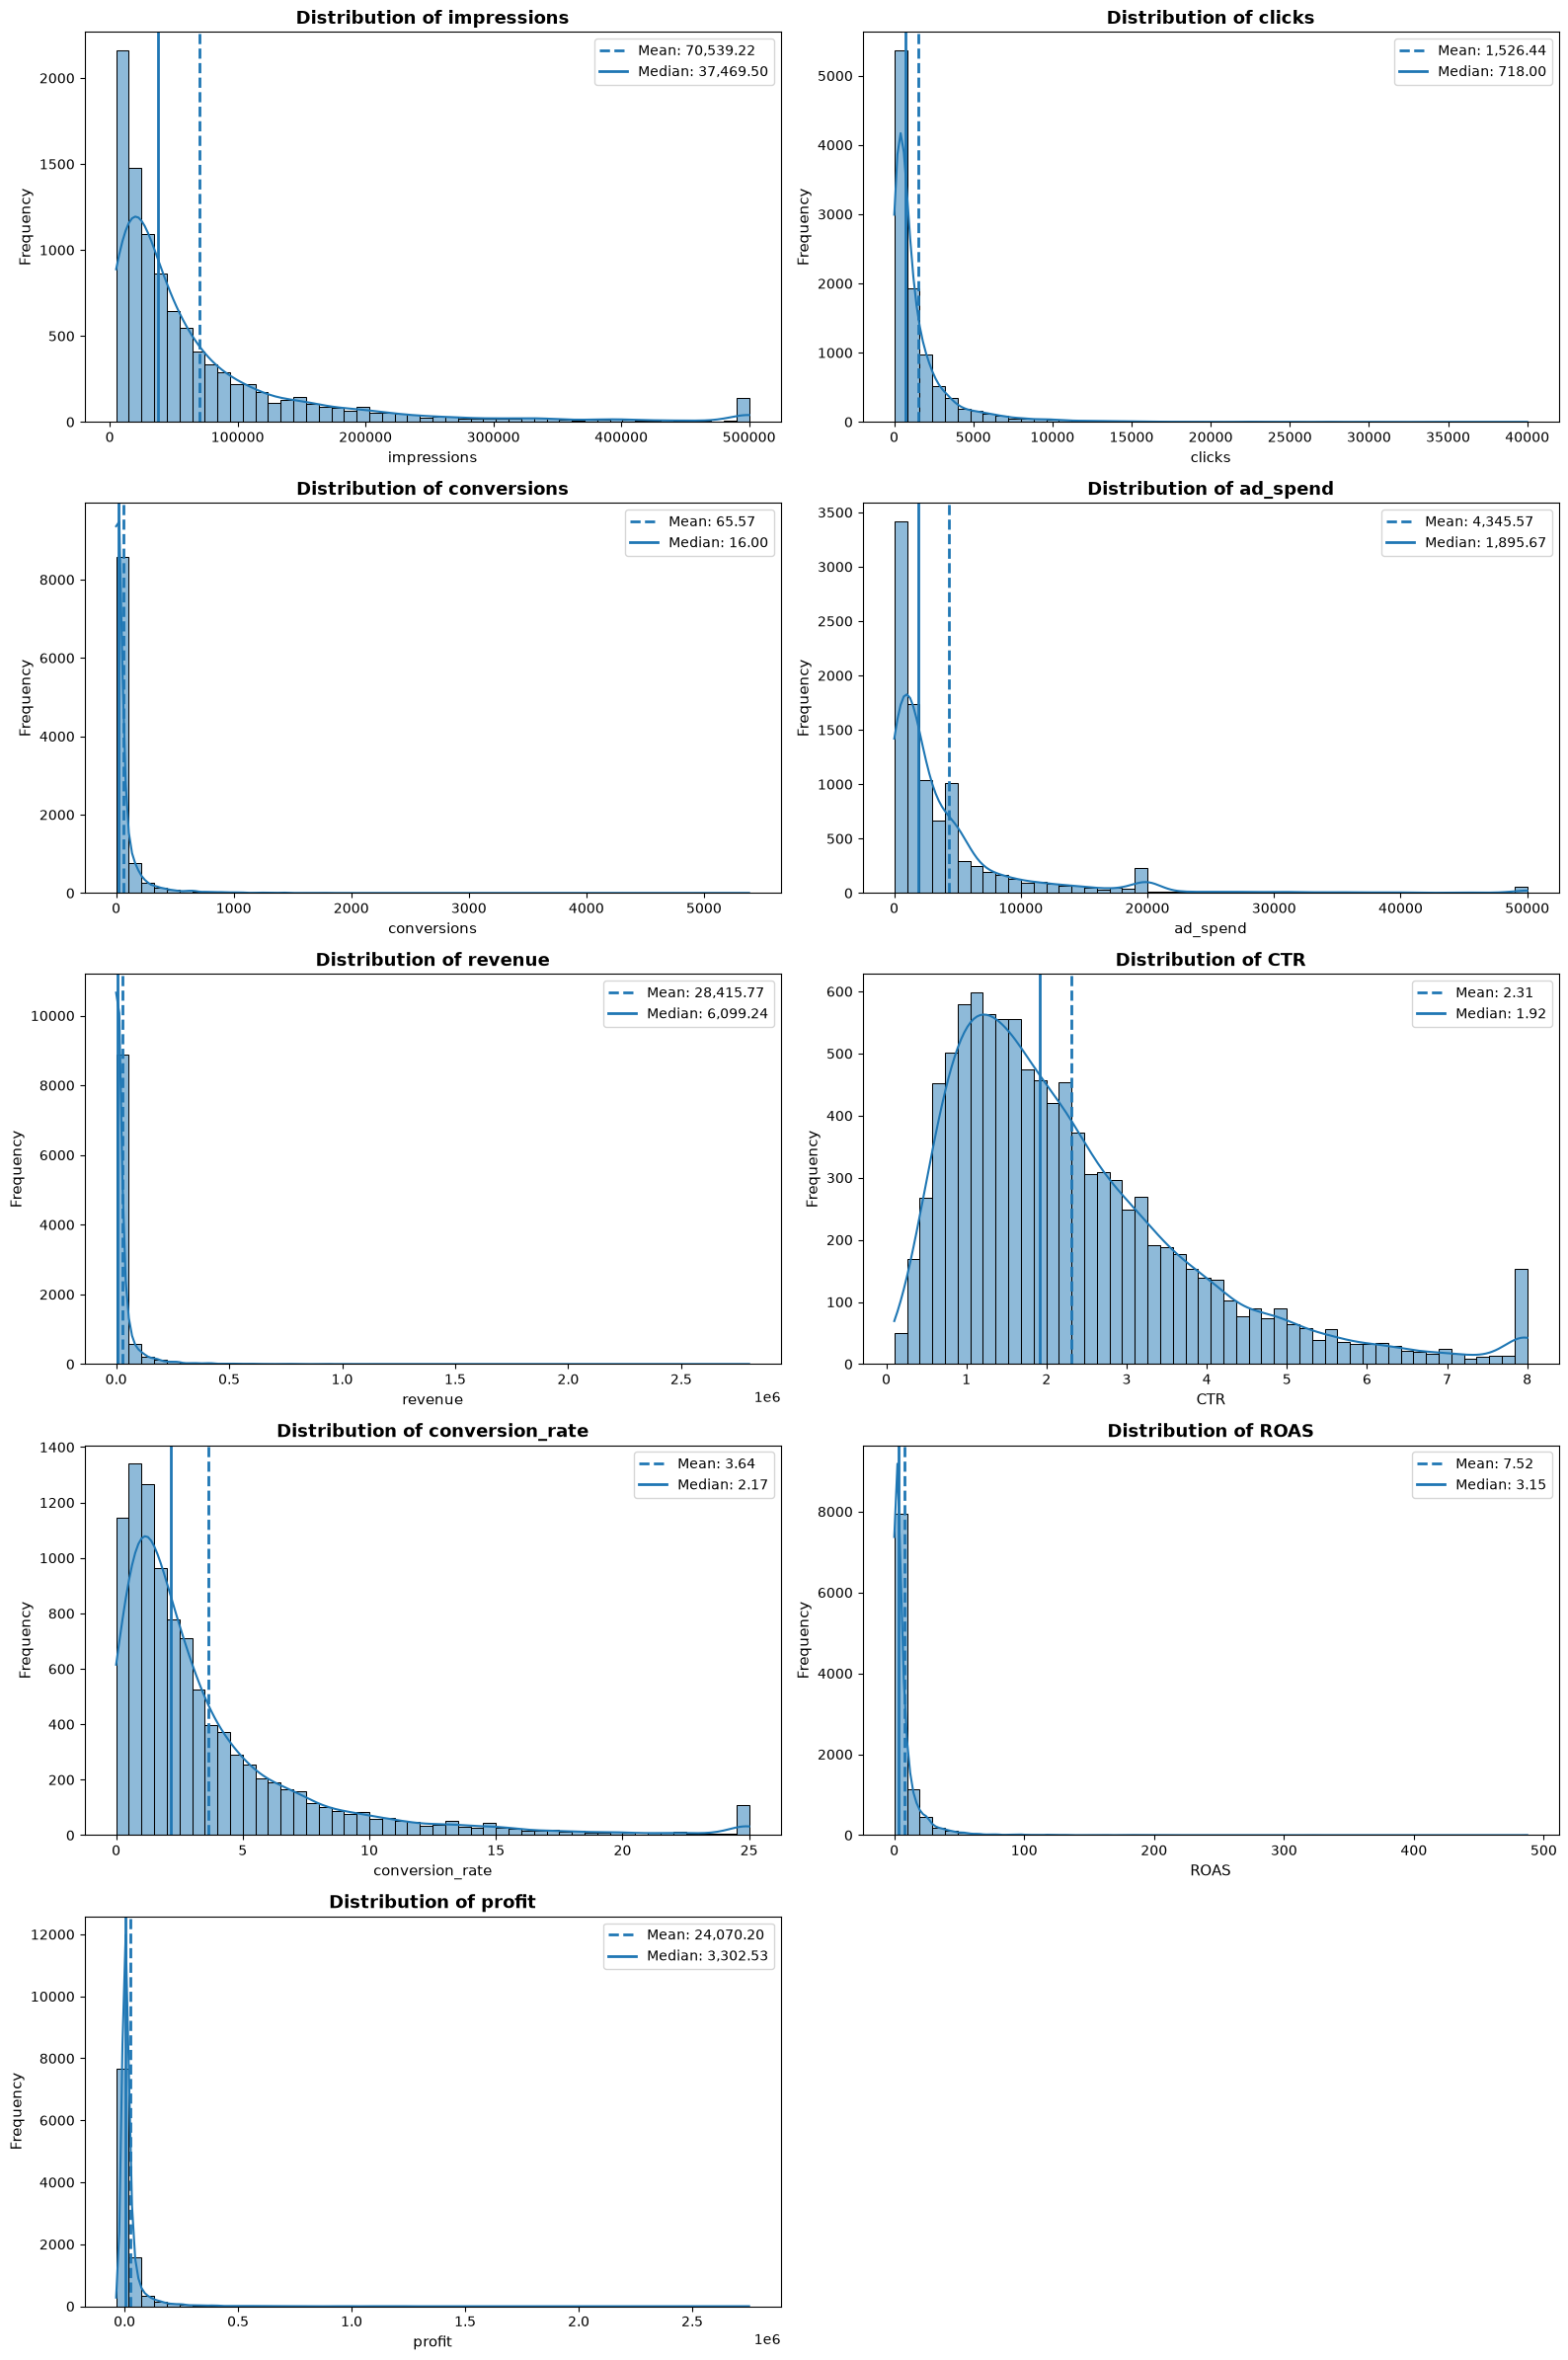

In [21]:
key_metrics = [
    "impressions",
    "clicks",
    "conversions",
    "ad_spend",
    "revenue",
    "CTR",
    "conversion_rate",
    "ROAS",
    "profit"
]

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, column in enumerate(key_metrics):
    
    sns.histplot(
        data=df,
        x=column,
        bins=50,
        kde=True,
        ax=axes[i]
    )
    
    # Mean
    axes[i].axvline(
        df[column].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean: {df[column].mean():,.2f}"
    )
    
    # Median
    axes[i].axvline(
        df[column].median(),
        linestyle="-",
        linewidth=2,
        label=f"Median: {df[column].median():,.2f}"
    )
    
    axes[i].set_title(
        f"Distribution of {column}",
        fontsize=13,
        fontweight="bold"
    )
    
    axes[i].set_xlabel(column, fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    
    axes[i].legend()

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

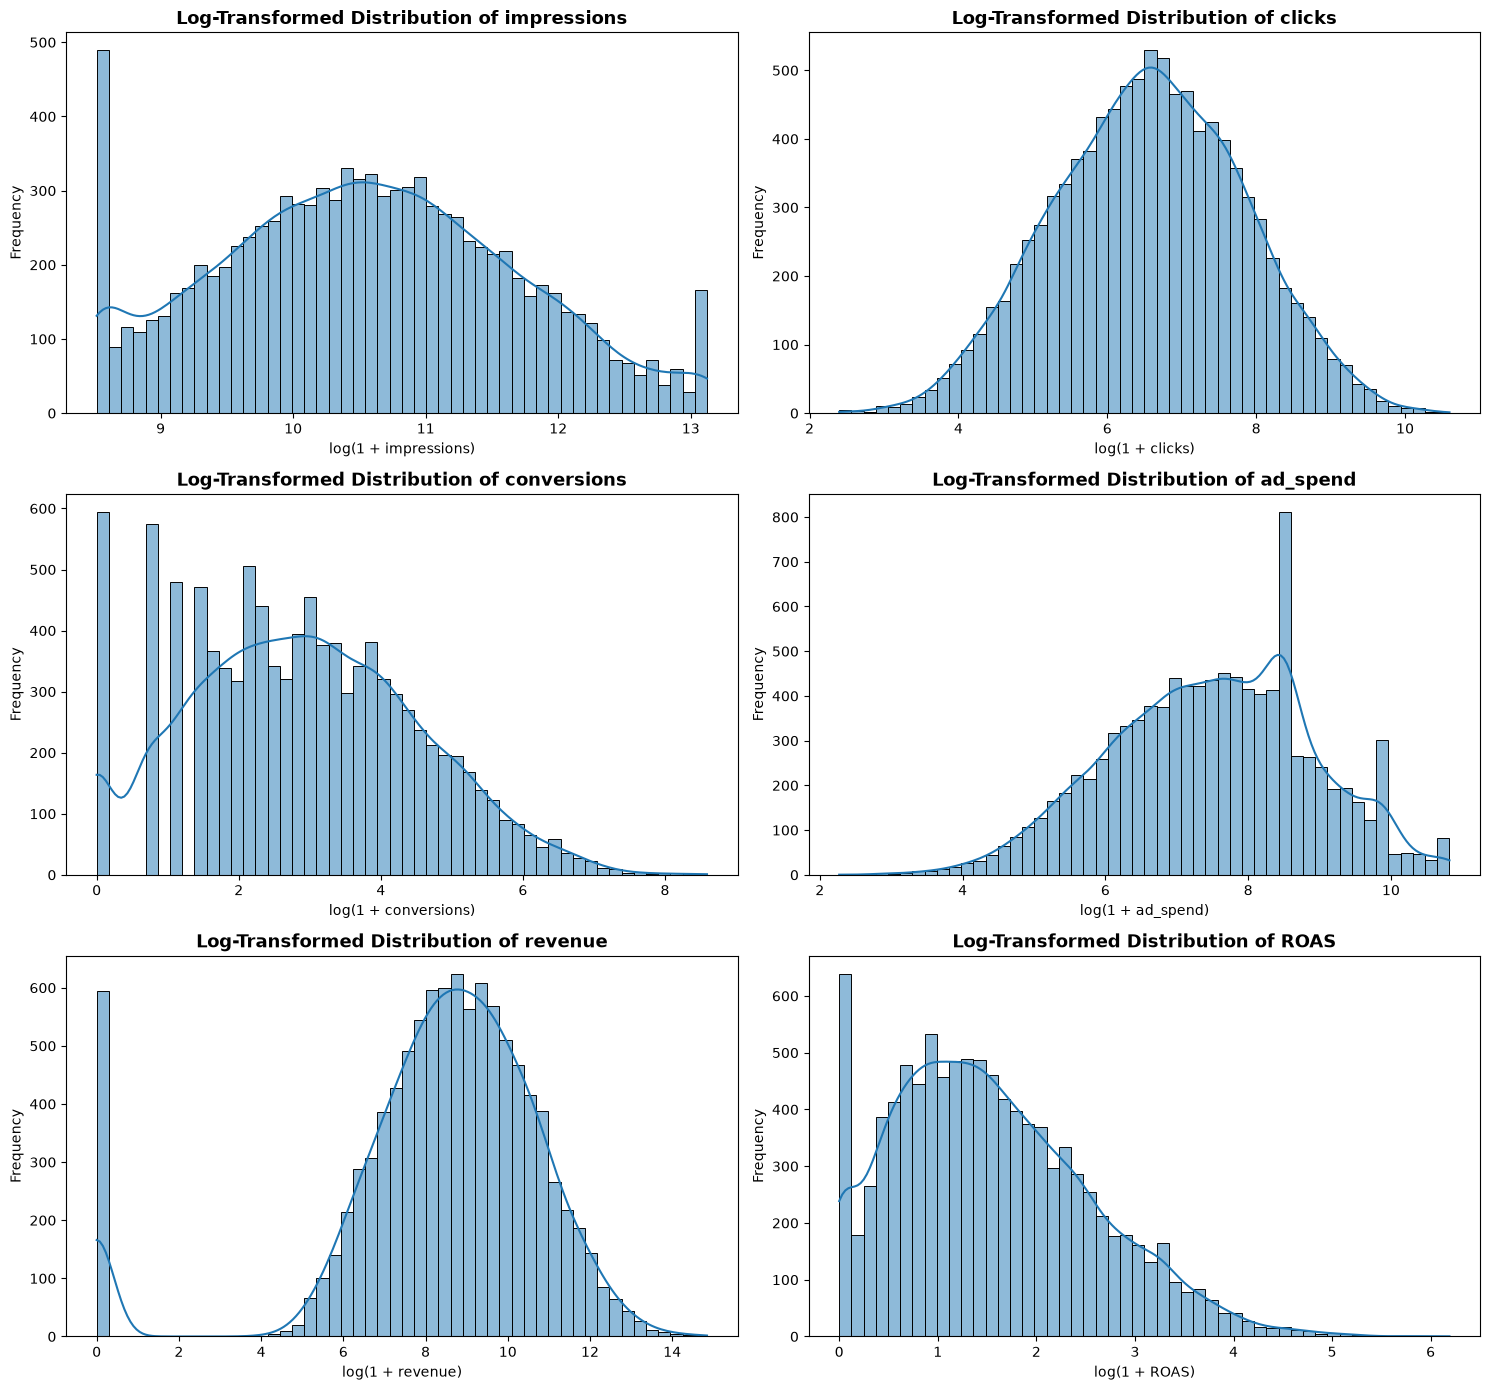

In [22]:
skewed_metrics = [
    "impressions",
    "clicks",
    "conversions",
    "ad_spend",
    "revenue",
    "ROAS"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for i, column in enumerate(skewed_metrics):
    
    log_values = np.log1p(df[column])
    
    sns.histplot(
        log_values,
        bins=50,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(
        f"Log-Transformed Distribution of {column}",
        fontsize=13,
        fontweight="bold"
    )
    
    axes[i].set_xlabel(f"log(1 + {column})")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of Key Metric Distributions

The distribution analysis shows that several campaign performance variables are strongly positively skewed. In particular, impressions, clicks, conversions, ad spend, revenue, ROAS, and profit contain long right tails, indicating that a relatively small number of campaigns achieve exceptionally high performance values.

The difference between the mean and median is especially noticeable for revenue and profit, further confirming the influence of extreme high-performing campaigns.

Logarithmic transformations were used for visualization purposes to better understand the underlying distributions of highly skewed non-negative variables. The transformed distributions of impressions, clicks, revenue, and other campaign metrics appear substantially more balanced.

These findings suggest that extreme campaign values should not automatically be removed, as they may represent genuine high-performing campaigns rather than data errors. However, skewness and extreme values should be considered during subsequent modeling and feature engineering stages.

CTR and conversion rate are also positively skewed but remain interpretable in their original scale. Profit was not included in the simple logarithmic transformation because it contains both positive and negative values.

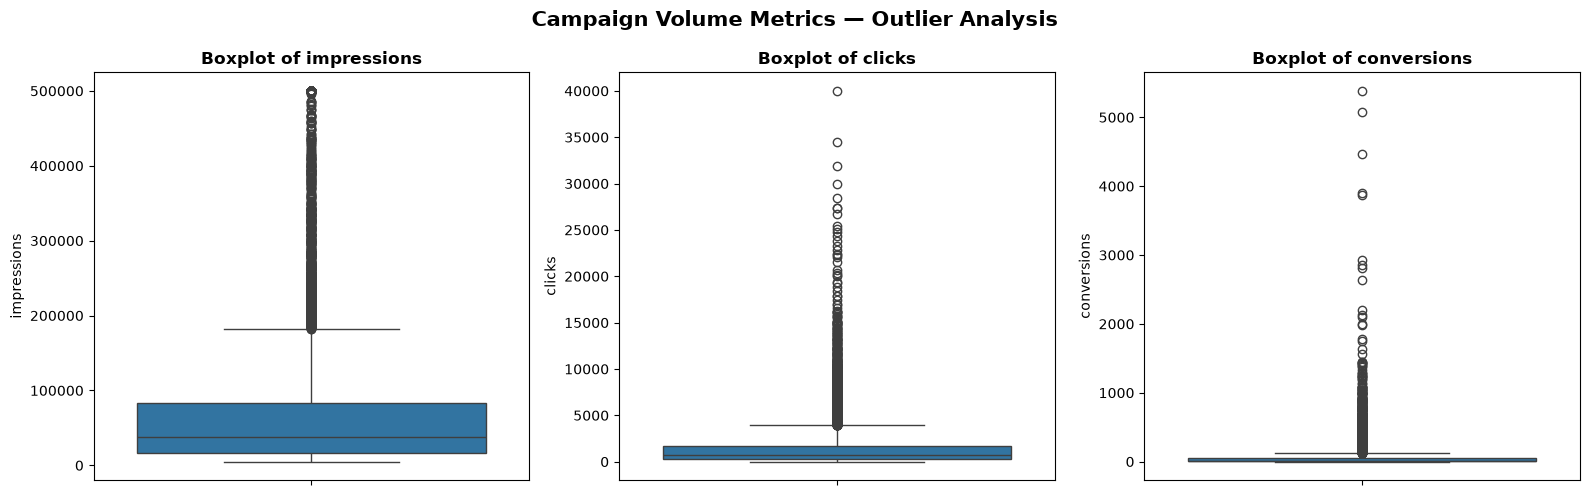

In [23]:
volume_metrics = [
    "impressions",
    "clicks",
    "conversions"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, column in zip(axes, volume_metrics):
    
    sns.boxplot(
        data=df,
        y=column,
        ax=ax
    )
    
    ax.set_title(
        f"Boxplot of {column}",
        fontsize=12,
        fontweight="bold"
    )
    
    ax.set_ylabel(column)

plt.suptitle(
    "Campaign Volume Metrics — Outlier Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

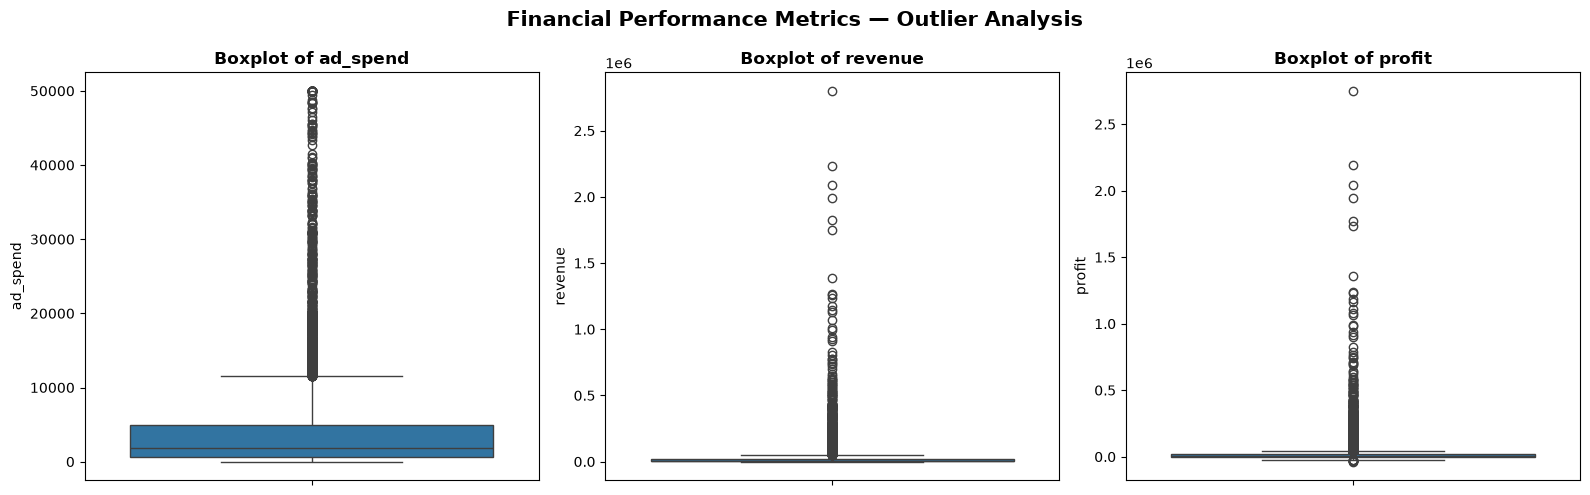

In [24]:
financial_metrics = [
    "ad_spend",
    "revenue",
    "profit"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, column in zip(axes, financial_metrics):
    
    sns.boxplot(
        data=df,
        y=column,
        ax=ax
    )
    
    ax.set_title(
        f"Boxplot of {column}",
        fontsize=12,
        fontweight="bold"
    )
    
    ax.set_ylabel(column)

plt.suptitle(
    "Financial Performance Metrics — Outlier Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

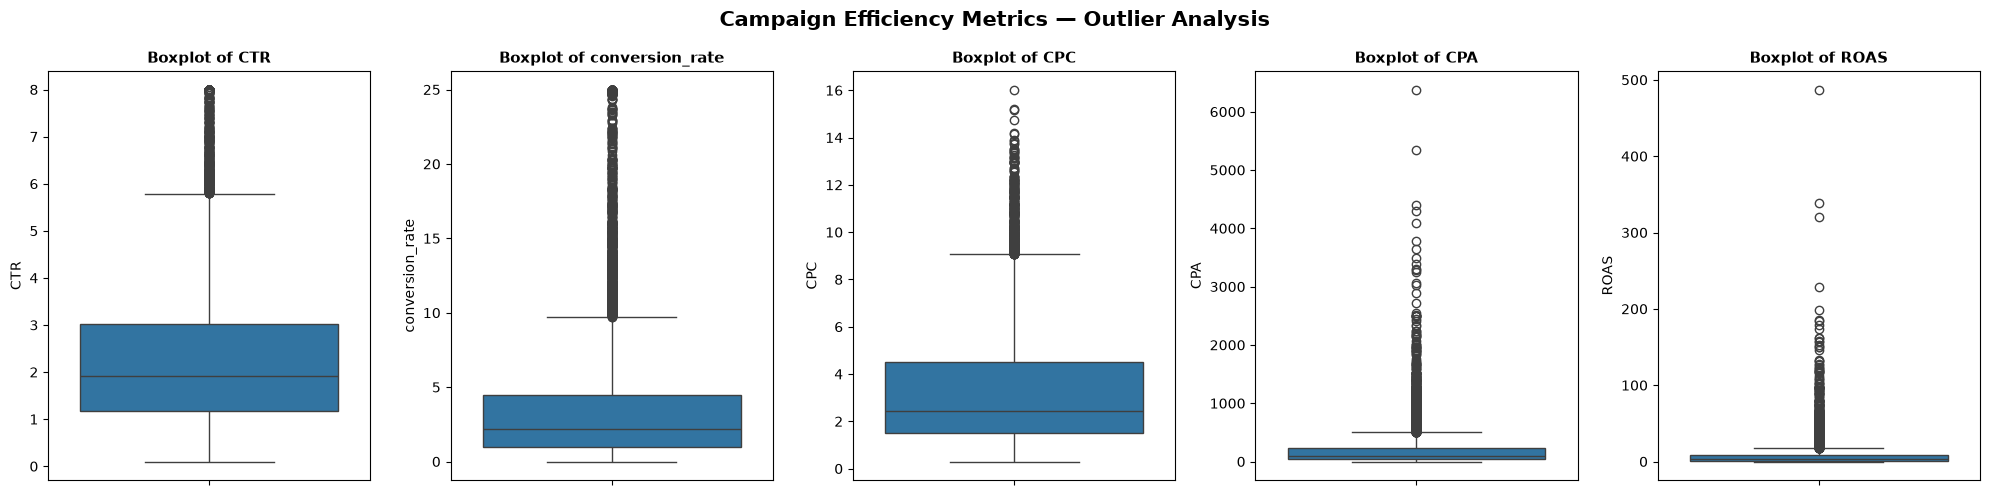

In [25]:
efficiency_metrics = [
    "CTR",
    "conversion_rate",
    "CPC",
    "CPA",
    "ROAS"
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, column in zip(axes, efficiency_metrics):
    
    sns.boxplot(
        data=df,
        y=column,
        ax=ax
    )
    
    ax.set_title(
        f"Boxplot of {column}",
        fontsize=11,
        fontweight="bold"
    )
    
    ax.set_ylabel(column)

plt.suptitle(
    "Campaign Efficiency Metrics — Outlier Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 3.4 Outlier Analysis

Boxplots were used to identify potential outliers in campaign efficiency, financial performance, and campaign volume metrics.

Several high-value observations were found, particularly in **CPA, ROAS, revenue, profit, impressions, clicks, and conversions**. These values may represent genuinely high-performing or high-budget campaigns rather than data errors.

Therefore, the outliers were retained for further analysis and will be handled appropriately during feature engineering and model development if necessary.

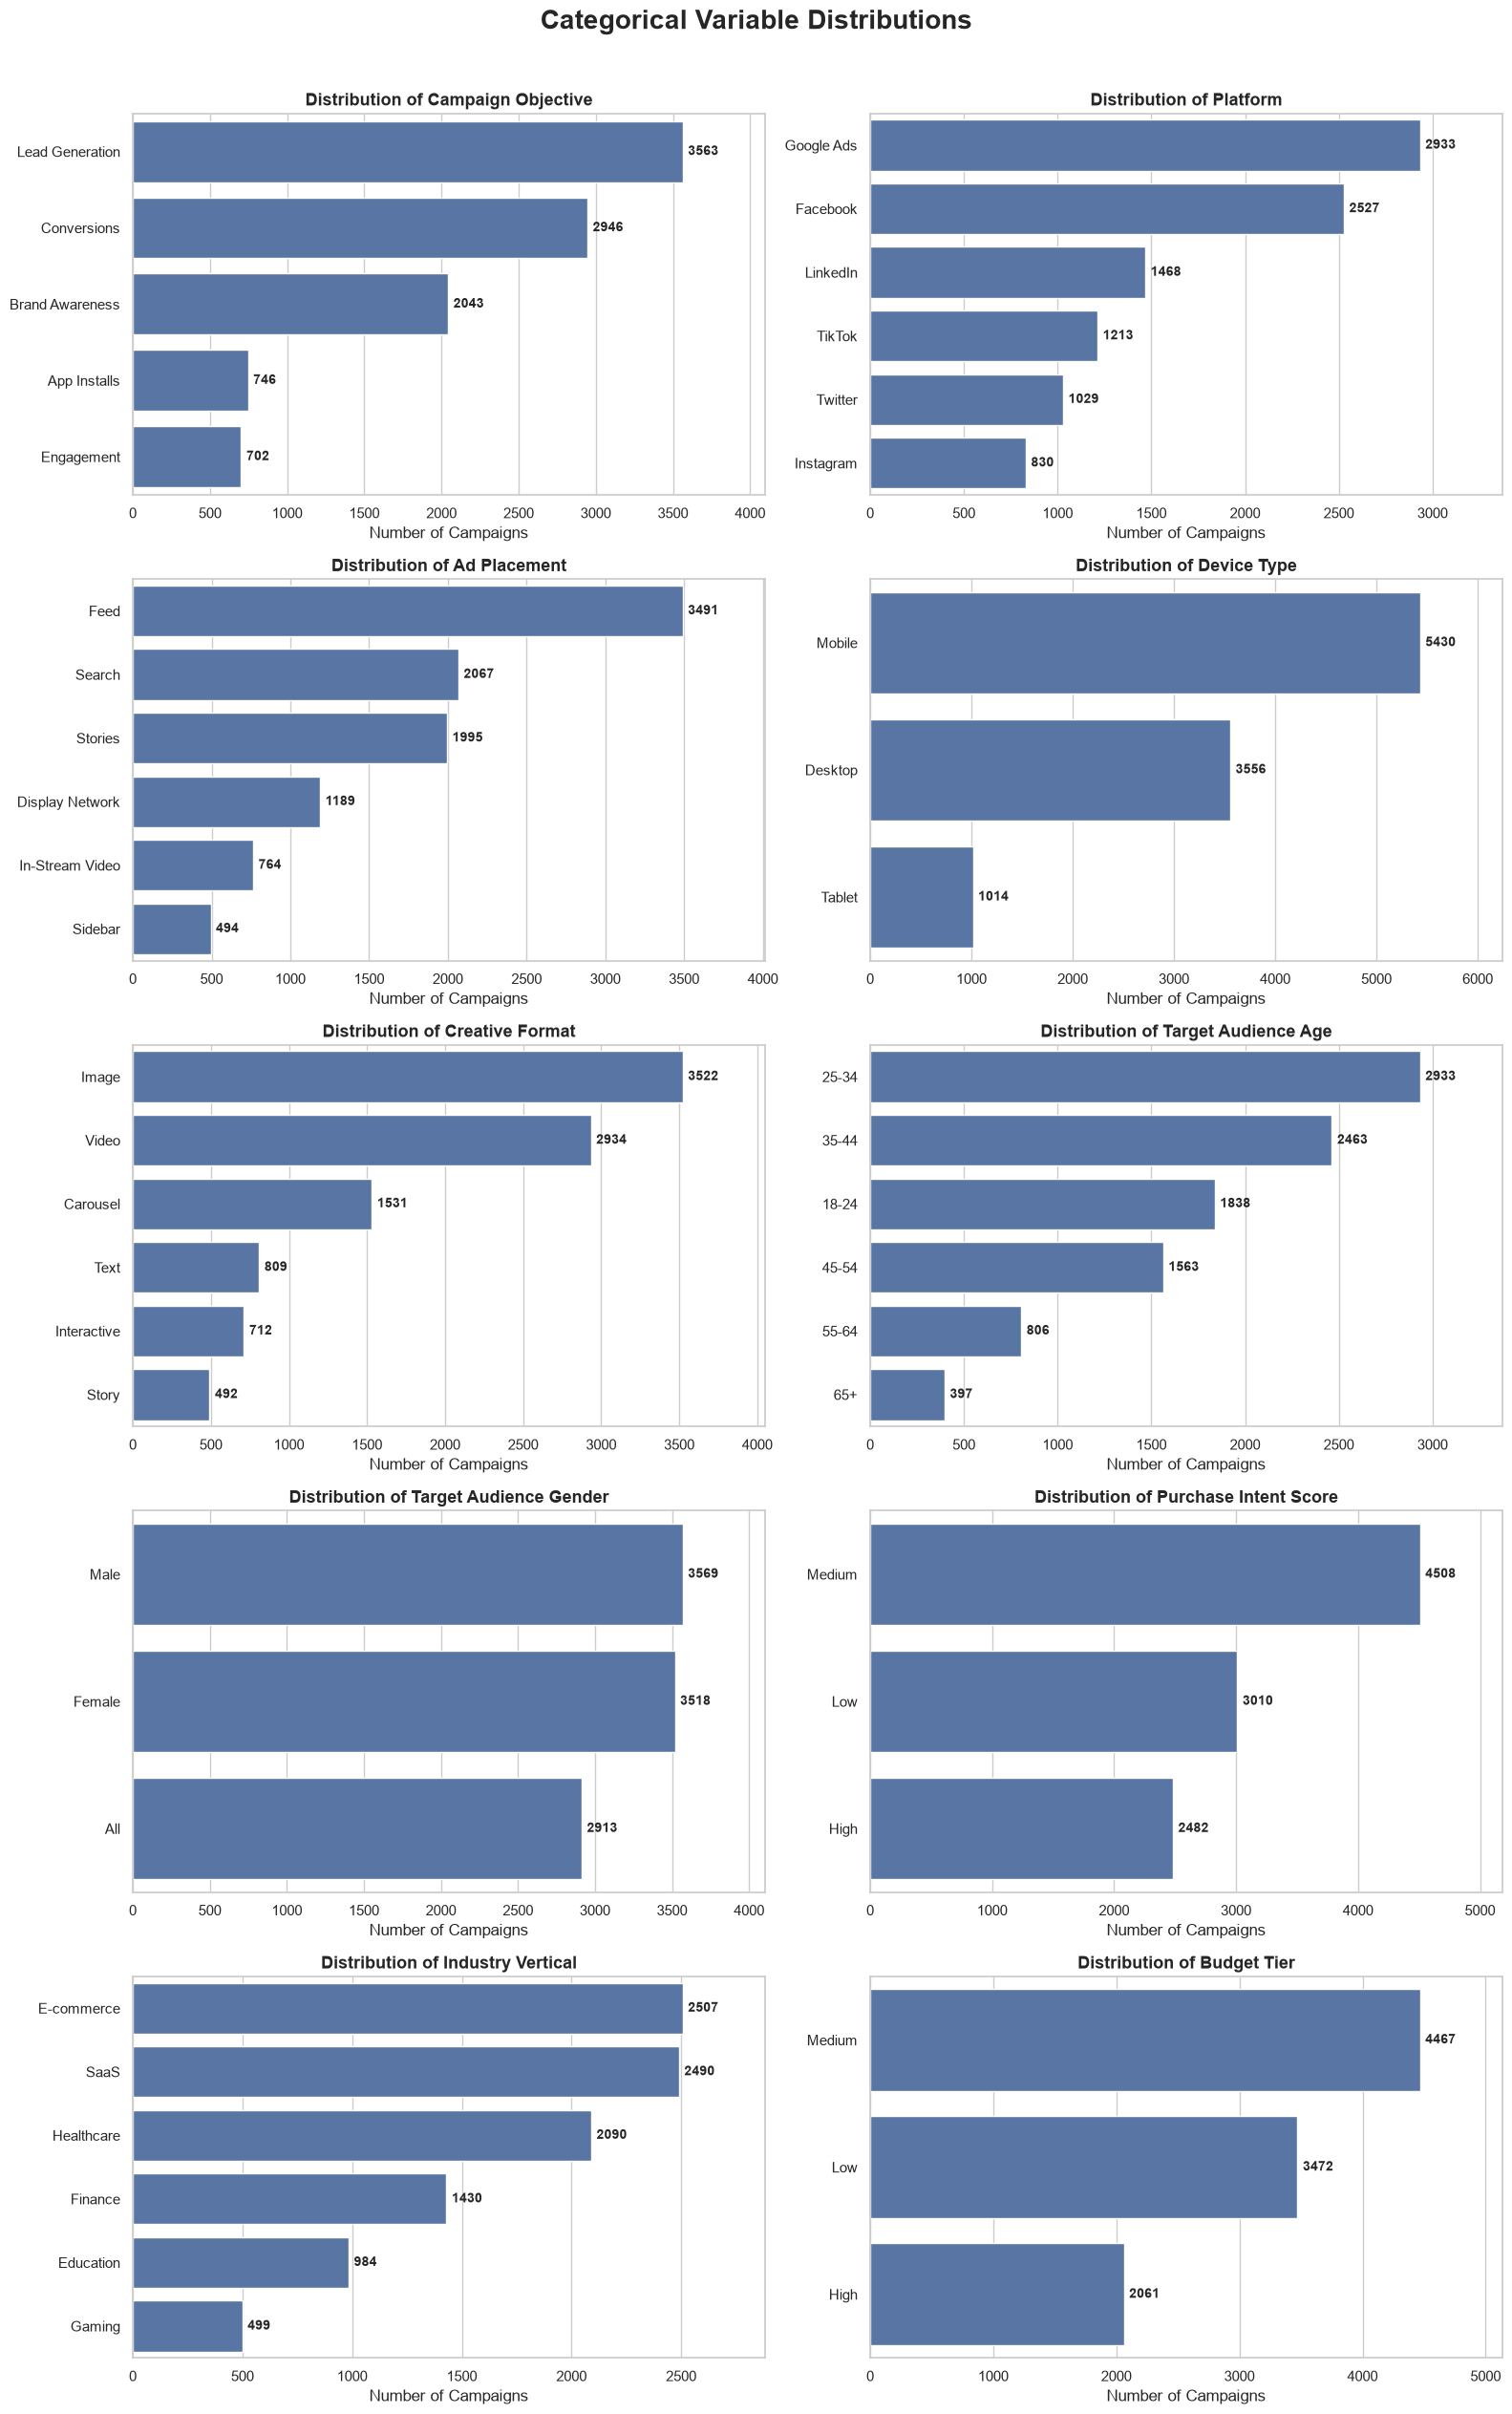

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set plotting style
sns.set_theme(style="whitegrid")

# Key categorical variables
categorical_cols = [
    "campaign_objective",
    "platform",
    "ad_placement",
    "device_type",
    "creative_format",
    "target_audience_age",
    "target_audience_gender",
    "purchase_intent_score",
    "industry_vertical",
    "budget_tier"
]

# Create subplot layout
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 5)
)

axes = axes.flatten()

# Create count plots
for i, column in enumerate(categorical_cols):

    # Order categories by frequency
    order = df[column].value_counts().index

    # Create plot
    sns.countplot(
        data=df,
        y=column,
        order=order,
        ax=axes[i]
    )

    # Add exact count labels to bars
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt="%d",
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

    # Formatting
    axes[i].set_title(
        f"Distribution of {column.replace('_', ' ').title()}",
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel("Number of Campaigns")
    axes[i].set_ylabel("")

    # Add some space for labels
    max_count = df[column].value_counts().max()
    axes[i].set_xlim(0, max_count * 1.15)

# Remove unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
plt.suptitle(
    "Categorical Variable Distributions",
    fontsize=20,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

### Campaign Performance Analysis by Platform

In [31]:
platform_performance = (
    df.groupby("platform")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(platform_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
platform,,,,,,,,,
Instagram,830,2.38,1.94,3.27,1.86,8.38,3.48,29005.03,4140.12
Google Ads,2933,2.17,1.82,4.60,2.90,5.76,2.74,27221.94,4923.00
TikTok,1213,2.45,2.00,2.36,1.42,10.85,4.23,25786.25,3136.30
Facebook,2527,2.42,2.03,3.43,2.07,10.01,4.44,25315.00,3760.71
Twitter,1029,2.42,1.93,2.61,1.51,8.23,3.59,17785.60,2281.00
LinkedIn,1468,2.19,1.81,4.09,2.46,3.05,1.46,15827.54,1061.46


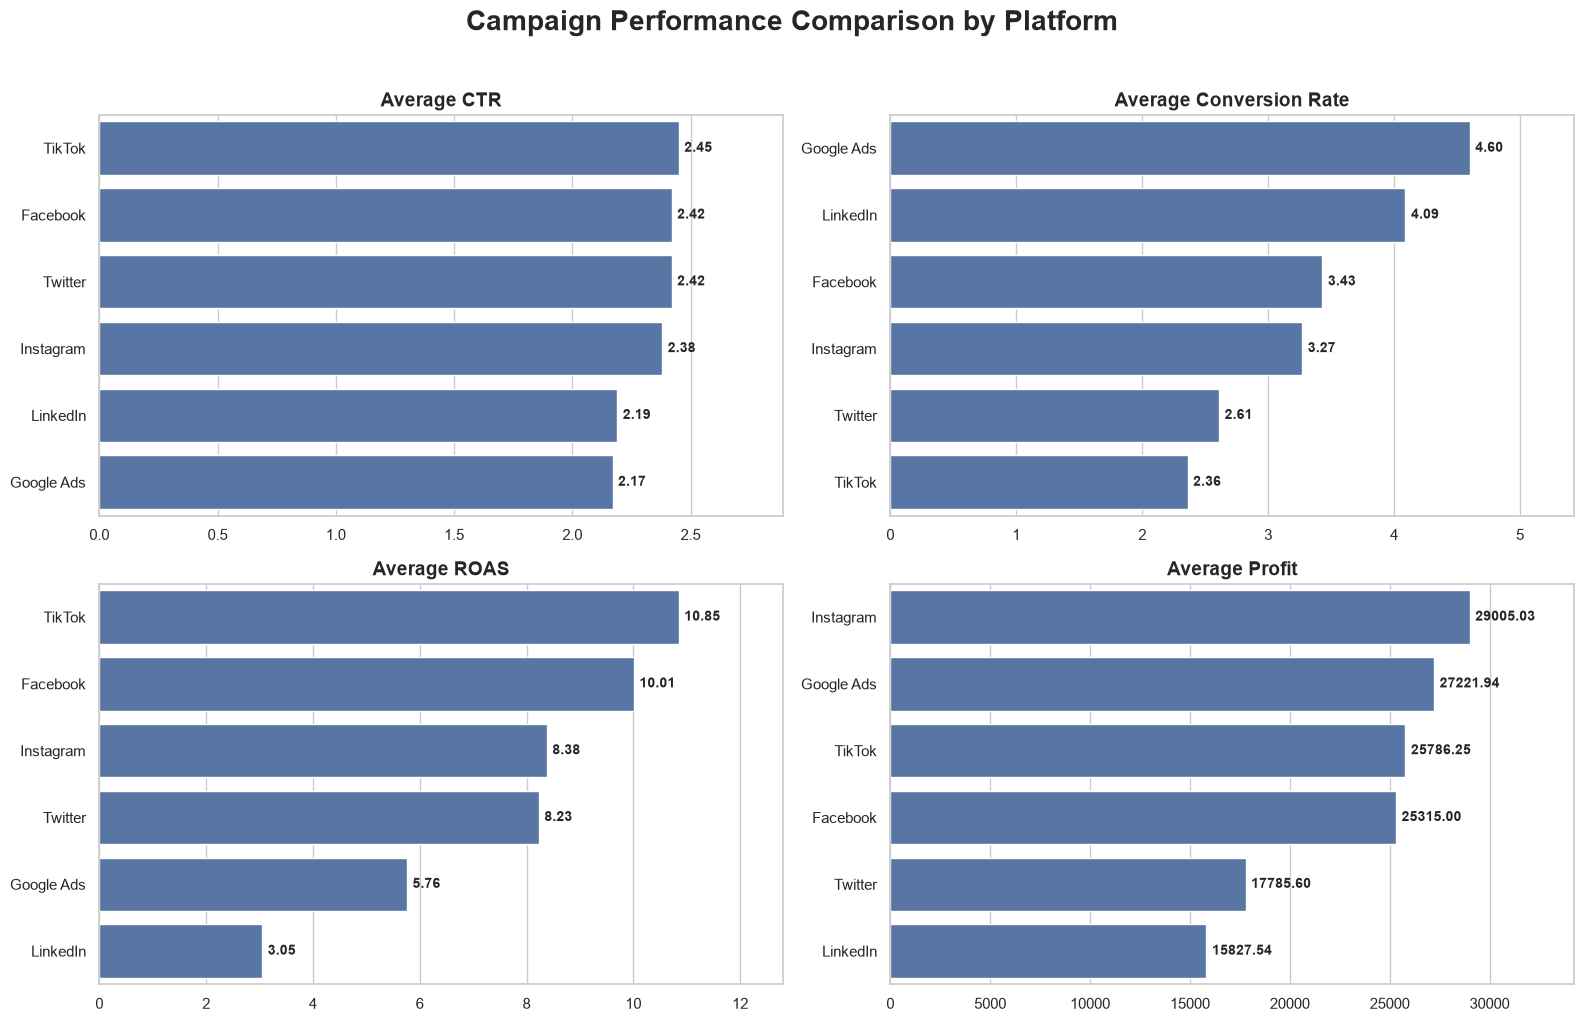

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for plotting
platform_plot = platform_performance.reset_index()

# KPI configuration
kpis = [
    ("Avg_CTR", "Average CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate"),
    ("Avg_ROAS", "Average ROAS"),
    ("Avg_Profit", "Average Profit")
]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

# Create bar charts
for ax, (column, title) in zip(axes, kpis):

    # Sort values for better comparison
    plot_data = platform_plot.sort_values(column, ascending=False)

    sns.barplot(
        data=plot_data,
        x=column,
        y="platform",
        ax=ax
    )

    # Add exact values to bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

    # Add space for labels
    max_value = plot_data[column].max()
    ax.set_xlim(0, max_value * 1.18)

    # Formatting
    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# Main title
plt.suptitle(
    "Campaign Performance Comparison by Platform",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Campaign Performance Analysis by Campaign Objective

In [33]:
objective_performance = (
    df.groupby("campaign_objective")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(objective_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
campaign_objective,,,,,,,,,
Conversions,2946,2.32,1.91,4.61,2.85,9.20,4.13,29844.68,4853.86
Lead Generation,3563,2.31,1.94,4.05,2.55,8.76,3.71,26542.98,4305.30
App Installs,746,2.45,2.01,3.29,2.03,6.30,2.86,19860.49,2562.20
Engagement,702,2.31,1.93,2.70,1.60,5.65,2.46,18820.96,2267.28
Brand Awareness,2043,2.27,1.83,1.99,1.17,4.06,1.70,14771.78,1100.51


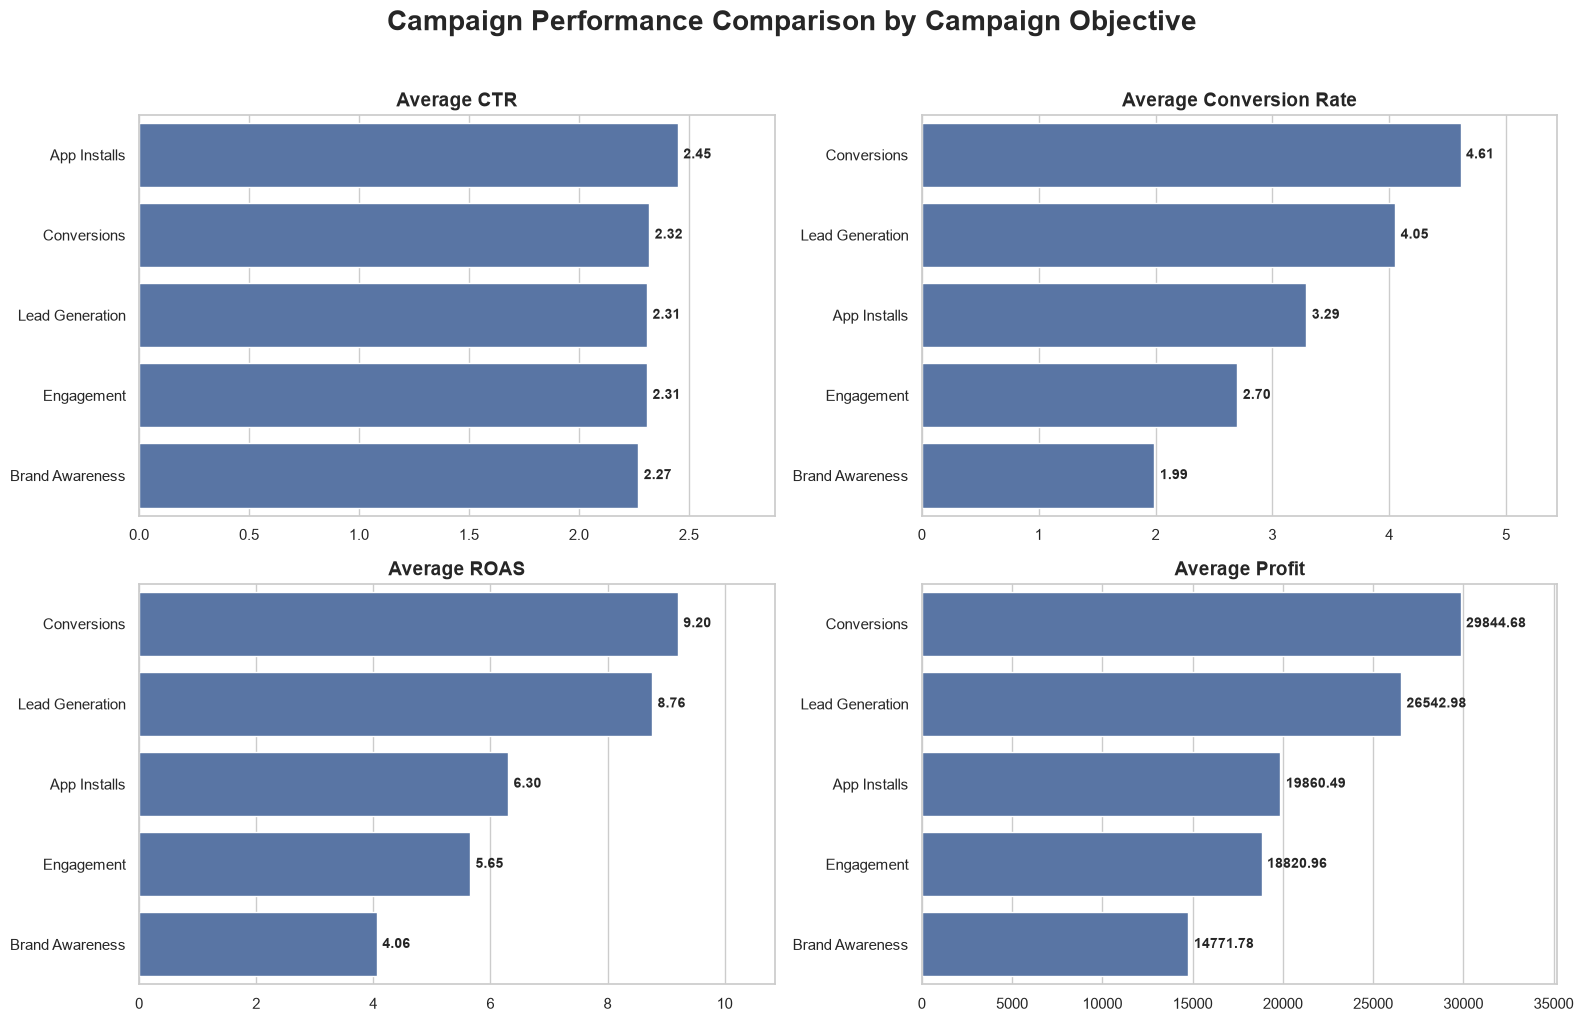

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for plotting
objective_plot = objective_performance.reset_index()

# KPI configuration
kpis = [
    ("Avg_CTR", "Average CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate"),
    ("Avg_ROAS", "Average ROAS"),
    ("Avg_Profit", "Average Profit")
]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

# Create bar charts
for ax, (column, title) in zip(axes, kpis):

    # Sort values for better comparison
    plot_data = objective_plot.sort_values(column, ascending=False)

    sns.barplot(
        data=plot_data,
        x=column,
        y="campaign_objective",
        ax=ax
    )

    # Add exact values to bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

    # Add space for value labels
    max_value = plot_data[column].max()
    ax.set_xlim(0, max_value * 1.18)

    # Formatting
    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# Main title
plt.suptitle(
    "Campaign Performance Comparison by Campaign Objective",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Campaign Performance Analysis by Creative Format

In [35]:
creative_performance = (
    df.groupby("creative_format")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(creative_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
creative_format,,,,,,,,,
Video,2934,3.11,2.71,4.47,2.78,9.05,4.04,35242.08,7035.94
Interactive,712,2.78,2.47,3.33,2.10,6.58,3.17,27575.92,3867.02
Carousel,1531,2.30,1.96,3.29,1.94,6.42,2.60,22720.82,2595.03
Image,3522,1.84,1.54,3.29,1.93,7.07,2.90,18876.06,2517.69
Story,492,2.10,1.83,3.33,1.91,8.30,2.59,18652.99,2226.86
Text,809,1.26,1.08,3.35,1.84,6.43,2.43,8928.76,1278.88


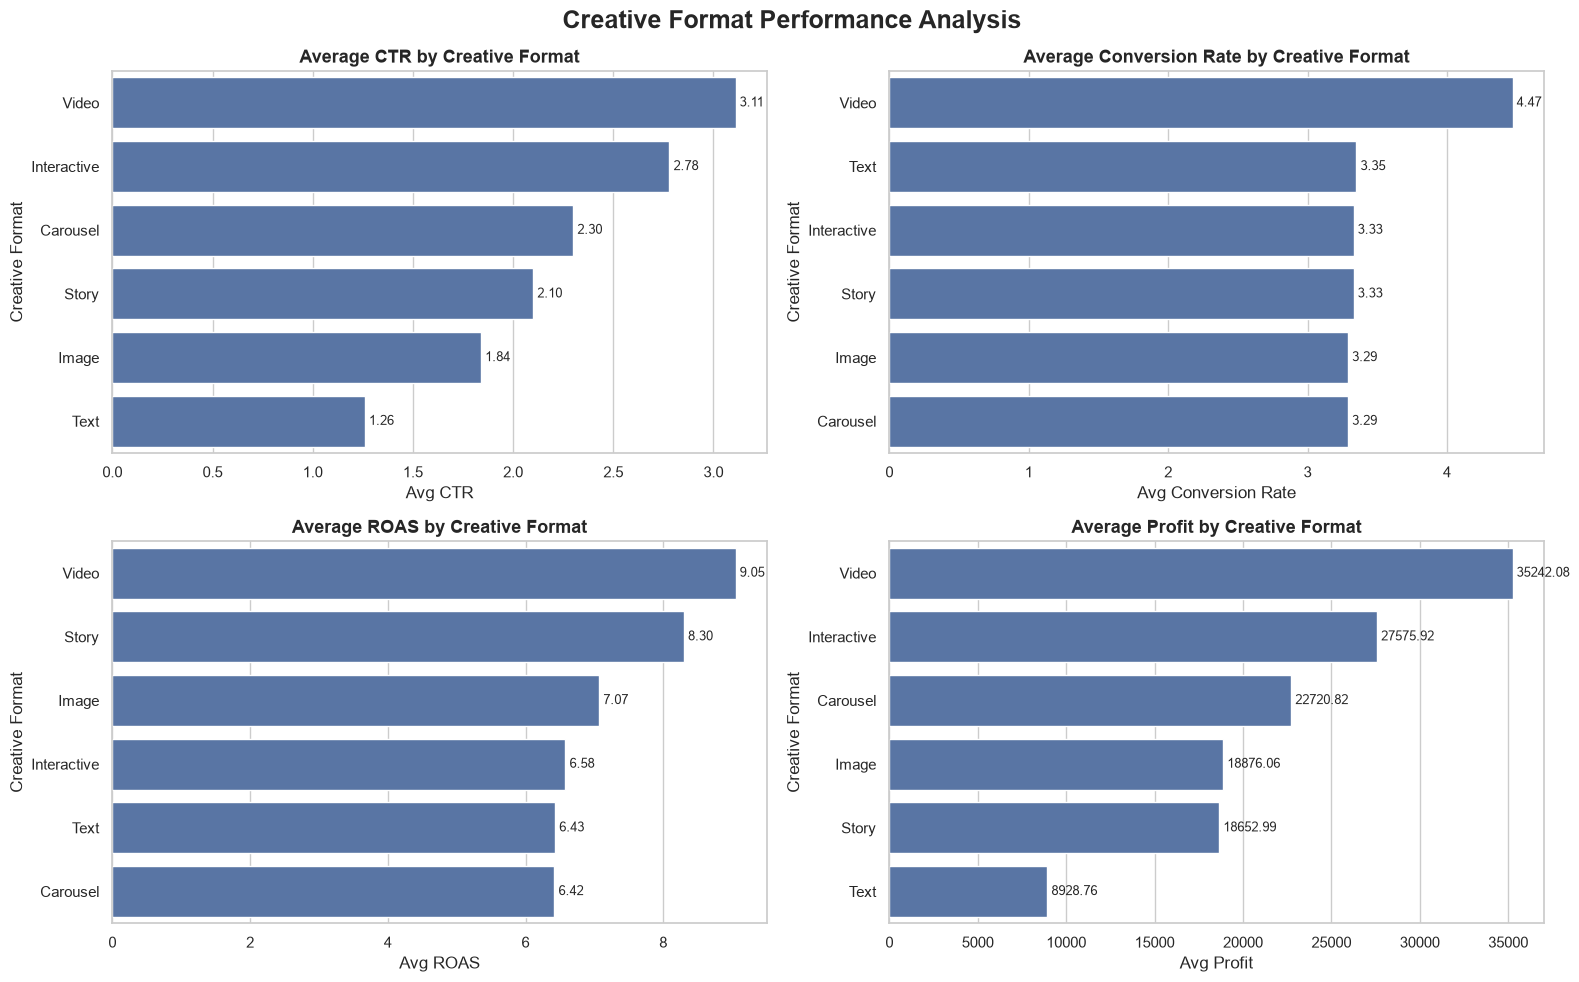

In [38]:
# ==========================================
# Creative Format Performance Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert index into a column for visualization
creative_plot = (
    creative_performance
    .reset_index()
)

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Creative Format Performance Analysis",
    fontsize=18,
    fontweight="bold"
)

# Define metrics to visualize
metrics = {
    "Avg_CTR": "Average CTR by Creative Format",
    "Avg_Conversion_Rate": "Average Conversion Rate by Creative Format",
    "Avg_ROAS": "Average ROAS by Creative Format",
    "Avg_Profit": "Average Profit by Creative Format"
}

# Create bar charts
for ax, (metric, title) in zip(axes.flatten(), metrics.items()):

    # Sort separately for each metric
    plot_data = creative_plot.sort_values(
        by=metric,
        ascending=False
    )

    sns.barplot(
        data=plot_data,
        x=metric,
        y="creative_format",
        ax=ax
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(metric.replace("_", " "))
    ax.set_ylabel("Creative Format")

    # Add exact values
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

#### Performance Analysis by Target Audience

In [39]:
# Performance analysis by target audience age

age_performance = (
    df.groupby("target_audience_age")
      .agg(
          Campaigns=("campaign_id", "count"),
          Avg_CTR=("CTR", "mean"),
          Median_CTR=("CTR", "median"),
          Avg_Conversion_Rate=("conversion_rate", "mean"),
          Median_Conversion_Rate=("conversion_rate", "median"),
          Avg_ROAS=("ROAS", "mean"),
          Median_ROAS=("ROAS", "median"),
          Avg_Profit=("profit", "mean"),
          Median_Profit=("profit", "median")
      )
      .round(2)
      .sort_values("Avg_Profit", ascending=False)
)

age_performance

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
target_audience_age,,,,,,,,,
18-24,1838,2.90,2.46,3.51,2.11,7.36,3.25,30263.07,3937.80
25-34,2933,2.55,2.18,3.61,2.19,7.50,3.12,25230.67,3577.83
35-44,2463,2.15,1.81,3.68,2.20,7.82,3.14,23301.11,3468.82
45-54,1563,1.92,1.59,3.75,2.13,7.87,3.10,20429.29,2783.64
55-64,806,1.77,1.51,3.89,2.28,7.00,3.32,19935.30,2590.22
65+,397,1.51,1.21,3.32,1.92,6.35,2.96,14326.18,2081.74


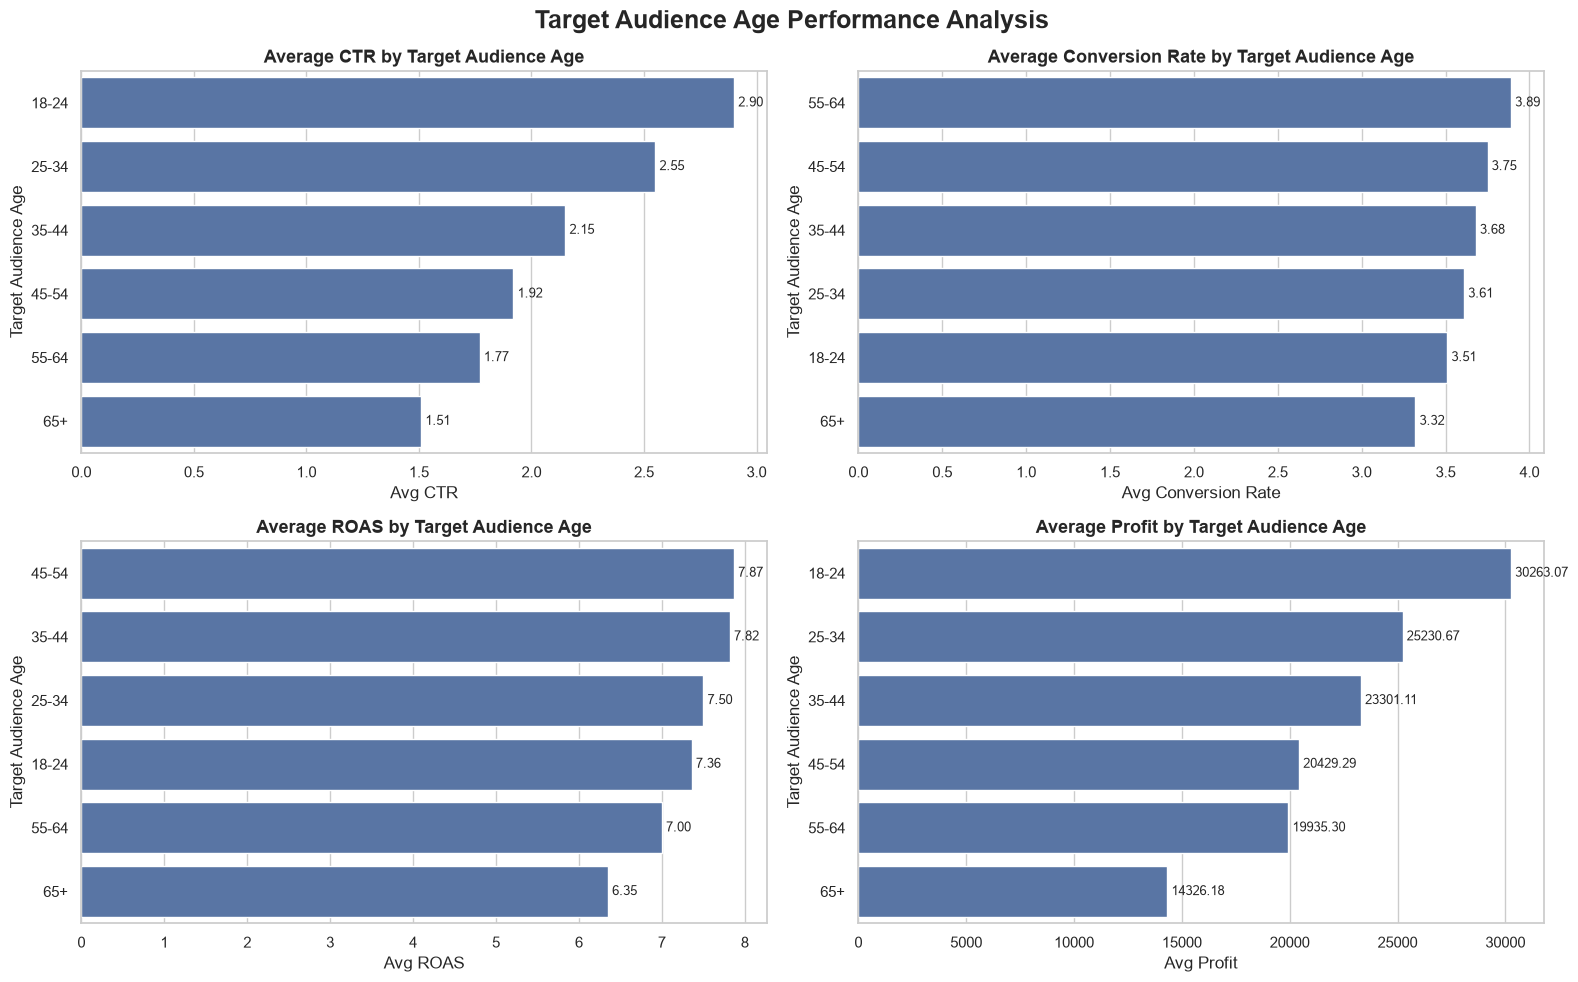

In [40]:
# ==========================================
# Target Audience Age Performance Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert index into a column
age_plot = age_performance.reset_index()

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Target Audience Age Performance Analysis",
    fontsize=18,
    fontweight="bold"
)

# Define metrics
metrics = {
    "Avg_CTR": "Average CTR by Target Audience Age",
    "Avg_Conversion_Rate": "Average Conversion Rate by Target Audience Age",
    "Avg_ROAS": "Average ROAS by Target Audience Age",
    "Avg_Profit": "Average Profit by Target Audience Age"
}

# Create visualizations
for ax, (metric, title) in zip(axes.flatten(), metrics.items()):

    plot_data = age_plot.sort_values(
        by=metric,
        ascending=False
    )

    sns.barplot(
        data=plot_data,
        x=metric,
        y="target_audience_age",
        ax=ax
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(metric.replace("_", " "))
    ax.set_ylabel("Target Audience Age")

    # Add exact values
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

#### Performance Analysis by Target Audience Gender

In [41]:
gender_performance = (
    df.groupby("target_audience_gender")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(gender_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
target_audience_gender,,,,,,,,,
All,2913,2.33,1.91,3.55,2.14,7.67,3.13,25266.10,3365.08
Female,3518,2.32,1.96,3.61,2.14,7.55,3.13,24374.98,3282.88
Male,3569,2.30,1.88,3.75,2.21,7.38,3.19,22793.70,3281.72


#### Performance Analysis by Purchase Intent Score

In [42]:
purchase_intent_performance = (
    df.groupby("purchase_intent_score")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(purchase_intent_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
purchase_intent_score,,,,,,,,,
High,2482,2.34,1.93,6.87,4.92,14.36,7.19,47652.10,11042.64
Medium,4508,2.31,1.90,3.08,2.09,6.32,3.01,20284.73,3090.14
Low,3010,2.30,1.93,1.83,1.21,3.69,1.70,10294.34,902.38


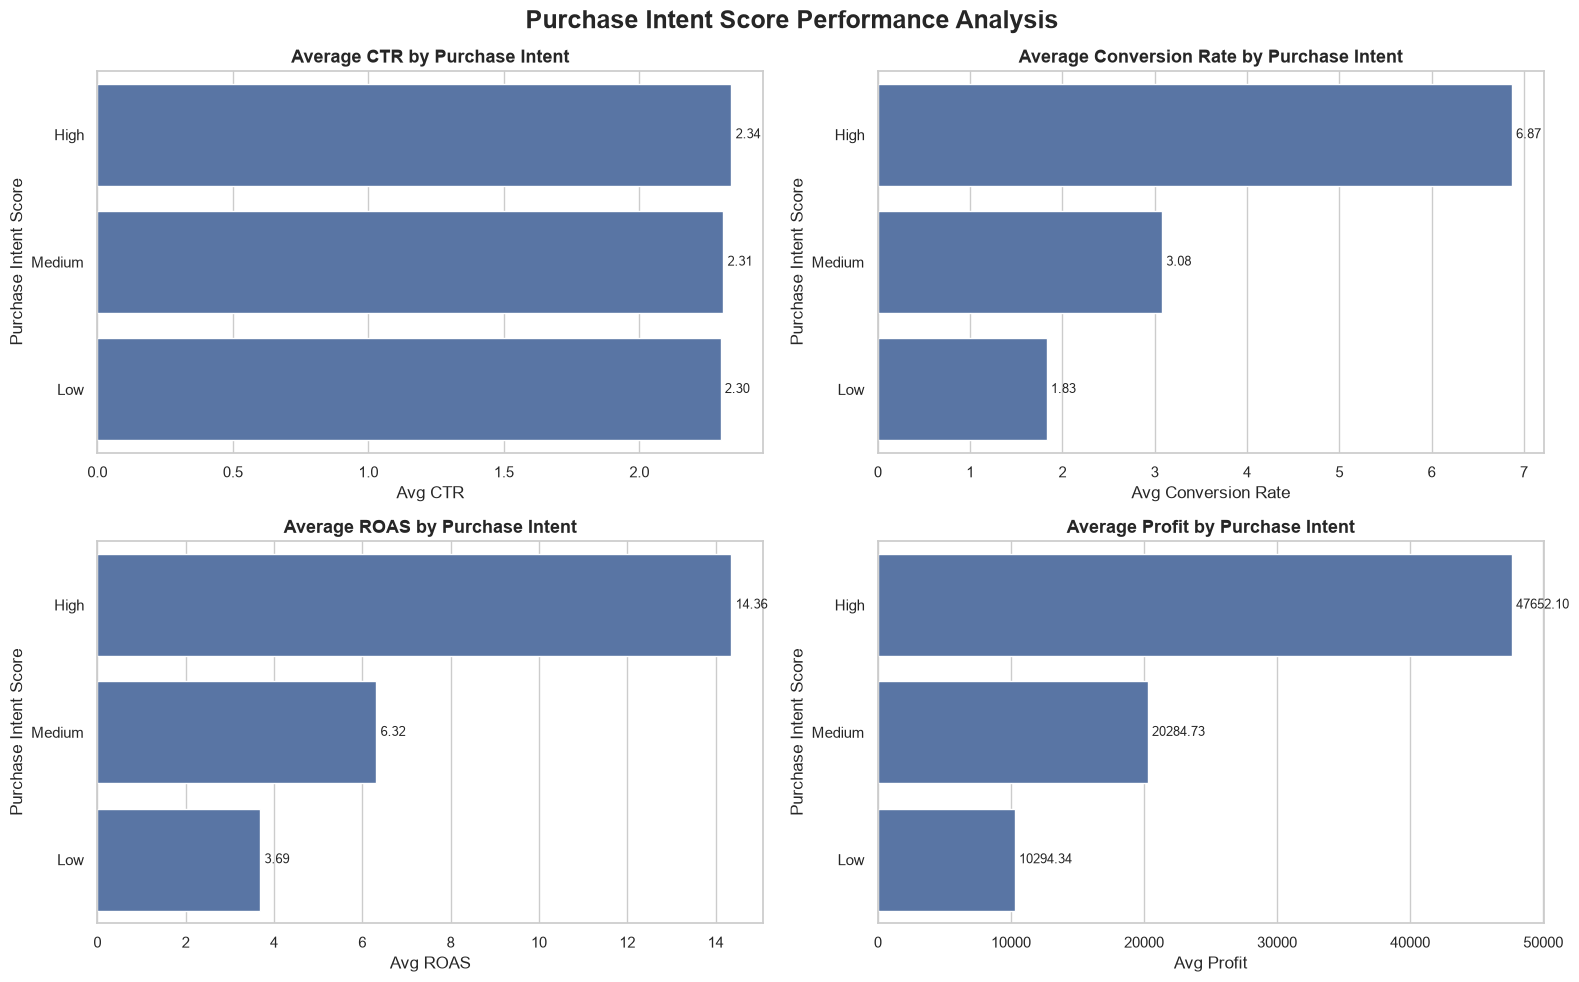

In [43]:
# ==========================================
# Purchase Intent Performance Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert index into a column
intent_plot = purchase_intent_performance.reset_index()

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Purchase Intent Score Performance Analysis",
    fontsize=18,
    fontweight="bold"
)

# Define metrics
metrics = {
    "Avg_CTR": "Average CTR by Purchase Intent",
    "Avg_Conversion_Rate": "Average Conversion Rate by Purchase Intent",
    "Avg_ROAS": "Average ROAS by Purchase Intent",
    "Avg_Profit": "Average Profit by Purchase Intent"
}

# Create charts
for ax, (metric, title) in zip(axes.flatten(), metrics.items()):

    plot_data = intent_plot.sort_values(
        by=metric,
        ascending=False
    )

    sns.barplot(
        data=plot_data,
        x=metric,
        y="purchase_intent_score",
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(metric.replace("_", " "))
    ax.set_ylabel("Purchase Intent Score")

    # Add exact values
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

#### Performance Analysis by Industry Vertical

In [44]:
industry_performance = (
    df.groupby("industry_vertical")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(industry_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
industry_vertical,,,,,,,,,
Finance,1430,2.47,2.06,3.88,2.39,12.72,5.67,45869.89,8355.54
Healthcare,2090,2.15,1.87,3.33,1.95,8.68,3.96,27007.27,5099.30
SaaS,2490,2.13,1.76,3.28,2.01,7.48,3.21,21158.86,3261.85
Education,984,2.43,2.05,3.74,2.33,5.95,2.84,19836.16,3199.03
E-commerce,2507,2.52,2.00,4.20,2.40,5.29,2.31,17595.29,1877.88
Gaming,499,2.22,1.82,3.14,2.04,2.31,1.12,4703.77,88.04


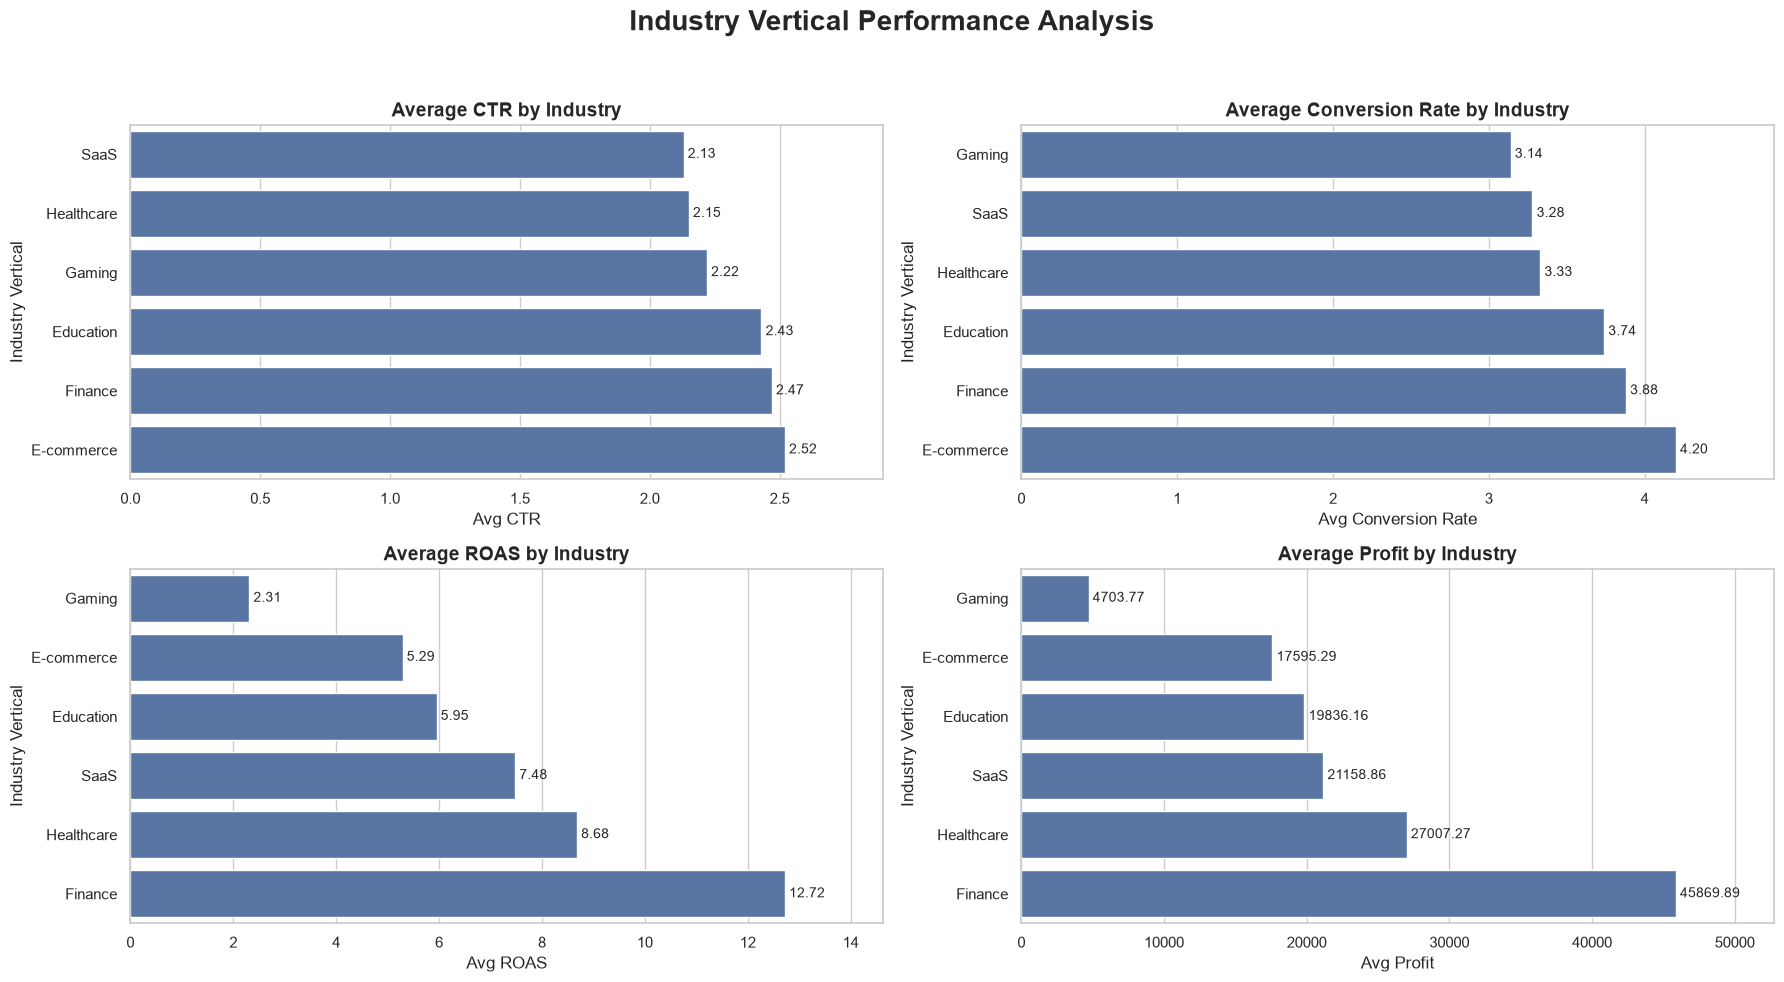

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for visualization
industry_plot = industry_performance.reset_index()

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

fig.suptitle(
    "Industry Vertical Performance Analysis",
    fontsize=20,
    fontweight="bold"
)

metrics = [
    ("Avg_CTR", "Average CTR by Industry", "Avg CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate by Industry", "Avg Conversion Rate"),
    ("Avg_ROAS", "Average ROAS by Industry", "Avg ROAS"),
    ("Avg_Profit", "Average Profit by Industry", "Avg Profit")
]

for ax, (metric, title, xlabel) in zip(axes.flat, metrics):

    plot_data = industry_plot.sort_values(metric, ascending=True)

    sns.barplot(
        data=plot_data,
        x=metric,
        y="industry_vertical",
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Industry Vertical")

    # Add exact values next to bars
    max_value = plot_data[metric].max()

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=10
        )

    ax.set_xlim(0, max_value * 1.15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Performance Analysis by Budget Tier

In [51]:
budget_performance = (
    df.groupby("budget_tier")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(budget_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
budget_tier,,,,,,,,,
High,2061,2.37,1.95,3.71,2.21,7.54,3.27,52220.18,9042.30
Medium,4467,2.36,1.96,3.72,2.21,7.80,3.20,22633.93,3736.37
Low,3472,2.22,1.86,3.51,2.06,7.16,3.01,9208.09,1876.20


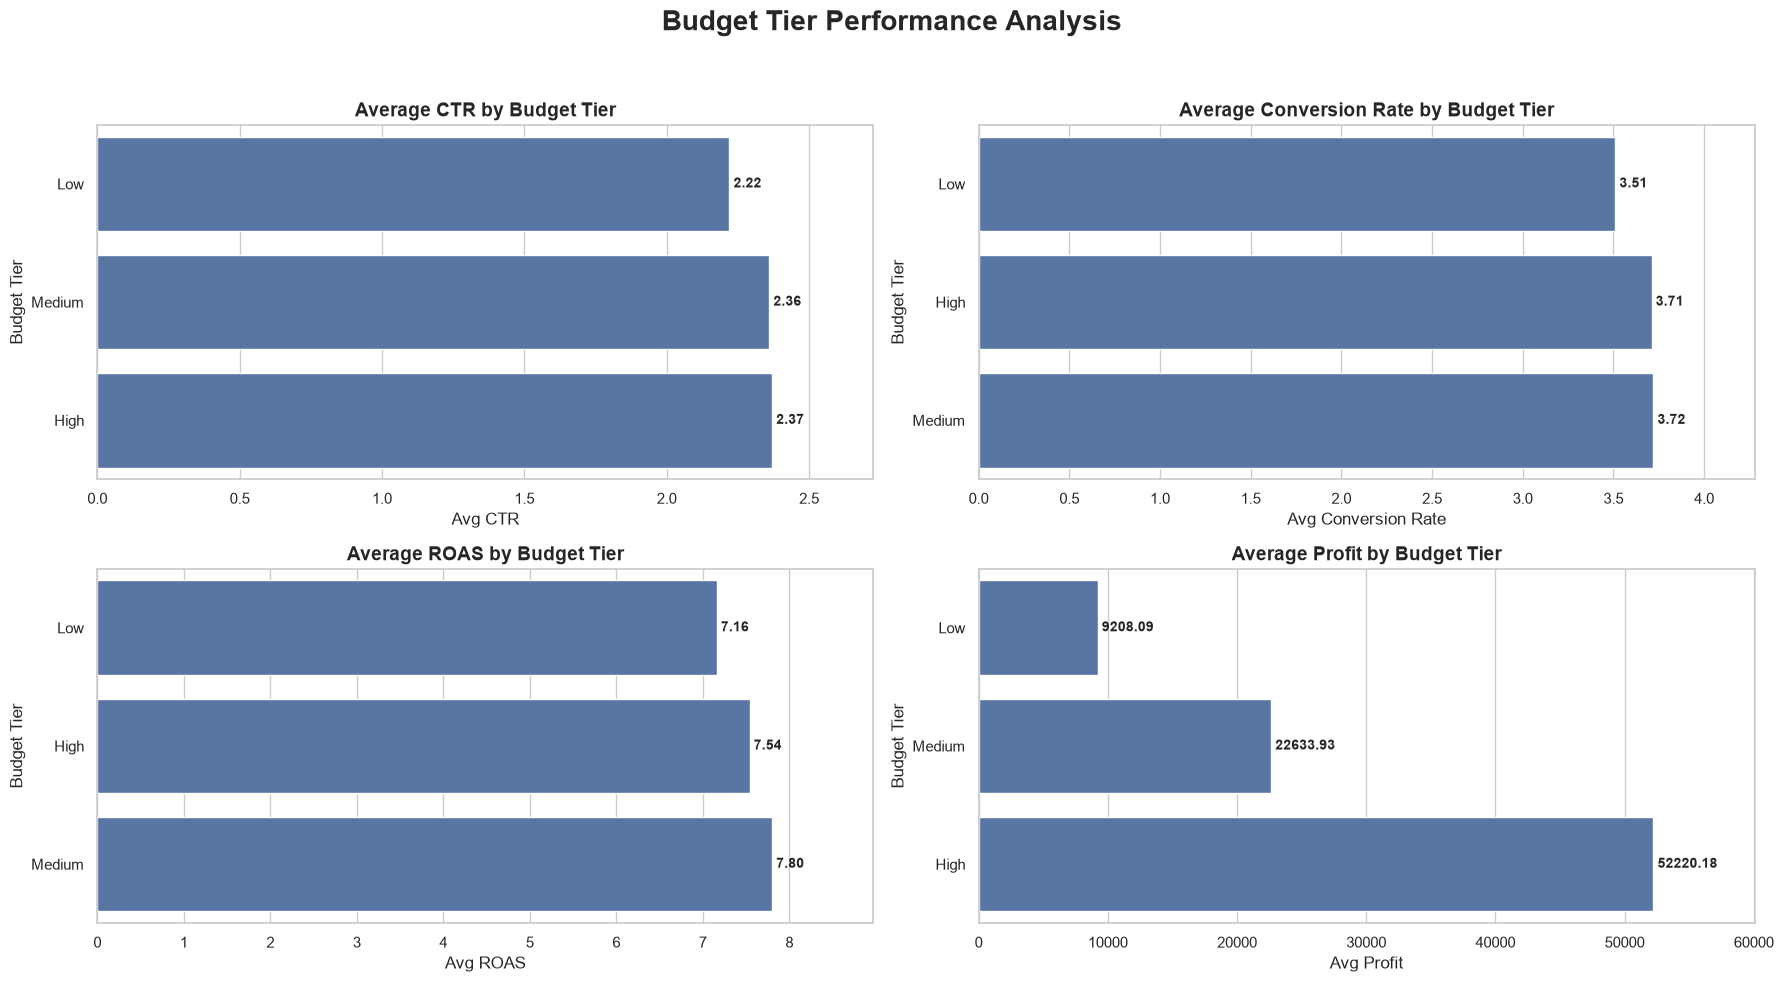

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for visualization
budget_plot = budget_performance.reset_index()

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

fig.suptitle(
    "Budget Tier Performance Analysis",
    fontsize=20,
    fontweight="bold"
)

metrics = [
    ("Avg_CTR", "Average CTR by Budget Tier", "Avg CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate by Budget Tier", "Avg Conversion Rate"),
    ("Avg_ROAS", "Average ROAS by Budget Tier", "Avg ROAS"),
    ("Avg_Profit", "Average Profit by Budget Tier", "Avg Profit")
]

for ax, (metric, title, xlabel) in zip(axes.flat, metrics):

    # Sort budget tiers by metric
    plot_data = budget_plot.sort_values(metric, ascending=True)

    sns.barplot(
        data=plot_data,
        x=metric,
        y="budget_tier",
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Budget Tier")

    # Add exact values next to bars
    max_value = plot_data[metric].max()

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=10,
            fontweight="bold"
        )

    # Add extra space for value labels
    ax.set_xlim(0, max_value * 1.15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Performance Analysis by Ad Placement.

In [54]:
placement_performance = (
    df.groupby("ad_placement")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_values("Avg_Profit", ascending=False)
)

display(placement_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
ad_placement,,,,,,,,,
Sidebar,494,2.44,2.02,3.75,2.27,8.09,3.11,34912.36,4178.00
Stories,1995,2.32,1.89,3.64,2.20,7.53,3.33,27451.19,4117.25
Feed,3491,2.29,1.92,3.56,2.16,7.25,3.16,22899.12,3242.25
Search,2067,2.34,1.90,3.74,2.15,7.59,3.05,22676.00,3003.77
Display Network,1189,2.28,1.91,3.58,2.11,7.95,2.97,21953.41,2495.26
In-Stream Video,764,2.29,1.93,3.81,2.14,7.57,3.22,20648.59,3615.54


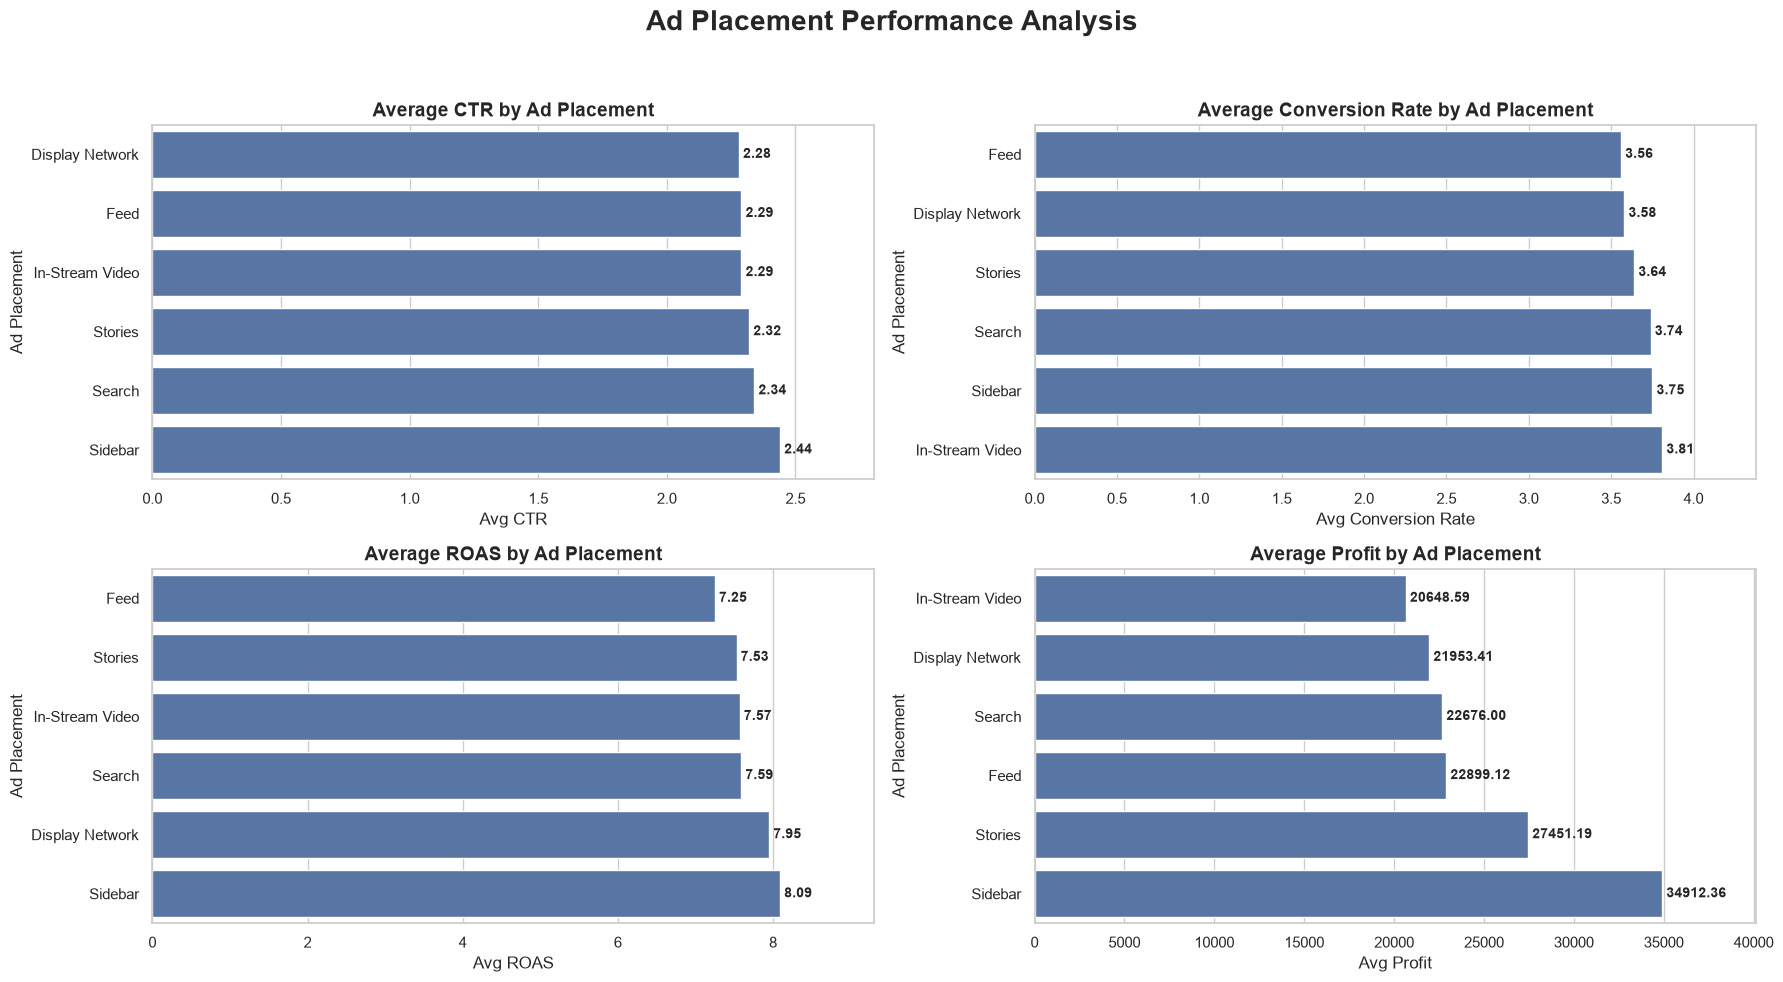

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for visualization
placement_plot = placement_performance.reset_index()

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

fig.suptitle(
    "Ad Placement Performance Analysis",
    fontsize=20,
    fontweight="bold"
)

metrics = [
    ("Avg_CTR", "Average CTR by Ad Placement", "Avg CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate by Ad Placement", "Avg Conversion Rate"),
    ("Avg_ROAS", "Average ROAS by Ad Placement", "Avg ROAS"),
    ("Avg_Profit", "Average Profit by Ad Placement", "Avg Profit")
]

for ax, (metric, title, xlabel) in zip(axes.flat, metrics):

    # Sort values for each metric
    plot_data = placement_plot.sort_values(
        metric,
        ascending=True
    )

    sns.barplot(
        data=plot_data,
        x=metric,
        y="ad_placement",
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Ad Placement")

    # Add exact values next to bars
    max_value = plot_data[metric].max()

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=10,
            fontweight="bold"
        )

    # Add space for labels
    ax.set_xlim(0, max_value * 1.15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Time-Based Performance Analysis.

In [56]:
quarter_performance = (
    df.groupby("quarter")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .sort_index()
)

display(quarter_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
quarter,,,,,,,,,
1,2871,2.21,1.87,3.50,2.21,7.76,3.16,22336.68,2996.90
2,2390,2.10,1.79,3.28,1.92,6.82,2.88,19266.43,2674.61
3,2416,1.98,1.64,3.04,1.82,6.25,2.54,18593.55,2063.52
4,2323,3.00,2.46,4.82,2.92,9.29,4.28,36850.91,6923.59


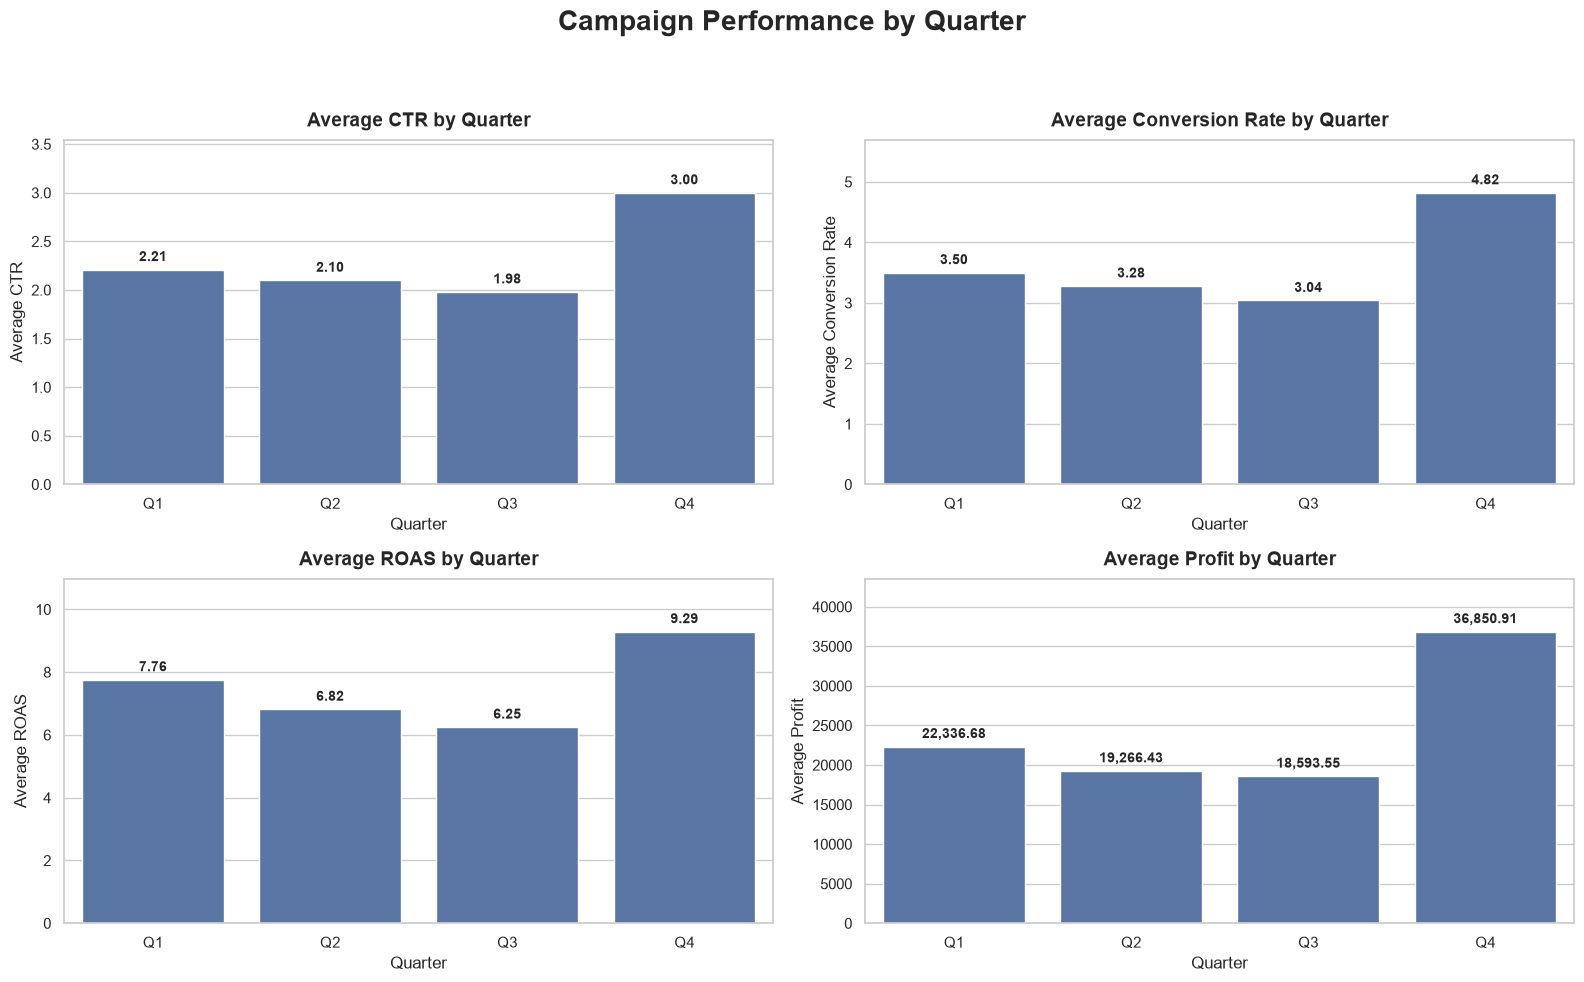

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for visualization
quarter_plot = quarter_performance.reset_index()

# Ensure correct quarter order
quarter_order = [1, 2, 3, 4]

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Campaign Performance by Quarter",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

metrics = [
    ("Avg_CTR", "Average CTR by Quarter", "Average CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate by Quarter", "Average Conversion Rate"),
    ("Avg_ROAS", "Average ROAS by Quarter", "Average ROAS"),
    ("Avg_Profit", "Average Profit by Quarter", "Average Profit")
]

for ax, (metric, title, ylabel) in zip(axes.flat, metrics):

    sns.barplot(
        data=quarter_plot,
        x="quarter",
        y=metric,
        order=quarter_order,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("Quarter")
    ax.set_ylabel(ylabel)

    # Add exact values above bars
    for container in ax.containers:
        labels = [
            f"{value:,.2f}" if metric == "Avg_Profit"
            else f"{value:.2f}"
            for value in quarter_plot[metric]
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

    # Add some space above bars
    max_value = quarter_plot[metric].max()
    ax.set_ylim(0, max_value * 1.18)

    # Improve quarter labels
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Performance Analysis by Day of Week.

In [64]:
# Define the correct chronological order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_performance = (
    df.groupby("day_of_week")
    .agg(
        Campaigns=("campaign_id", "count"),

        Avg_CTR=("CTR", "mean"),
        Median_CTR=("CTR", "median"),

        Avg_Conversion_Rate=("conversion_rate", "mean"),
        Median_Conversion_Rate=("conversion_rate", "median"),

        Avg_ROAS=("ROAS", "mean"),
        Median_ROAS=("ROAS", "median"),

        Avg_Profit=("profit", "mean"),
        Median_Profit=("profit", "median")
    )
    .round(2)
    .reindex(day_order)
)

display(day_performance)

,Campaigns,Avg_CTR,Median_CTR,Avg_Conversion_Rate,Median_Conversion_Rate,Avg_ROAS,Median_ROAS,Avg_Profit,Median_Profit
day_of_week,,,,,,,,,
Monday,1441,2.40,2.00,3.86,2.40,8.15,3.54,26157.94,4573.16
Tuesday,1471,2.45,2.08,3.82,2.37,7.96,3.47,25866.18,4029.81
Wednesday,1417,2.51,2.14,4.17,2.47,8.79,3.43,30260.81,4308.85
Thursday,1460,2.53,2.17,3.81,2.40,8.22,3.57,29151.46,4628.76
Friday,1358,2.43,2.07,3.92,2.41,8.75,3.51,29482.73,4320.38
Saturday,1435,1.91,1.48,3.06,1.70,5.76,2.38,14384.56,1527.49
Sunday,1418,1.96,1.53,2.88,1.60,5.06,2.33,13285.77,1459.36


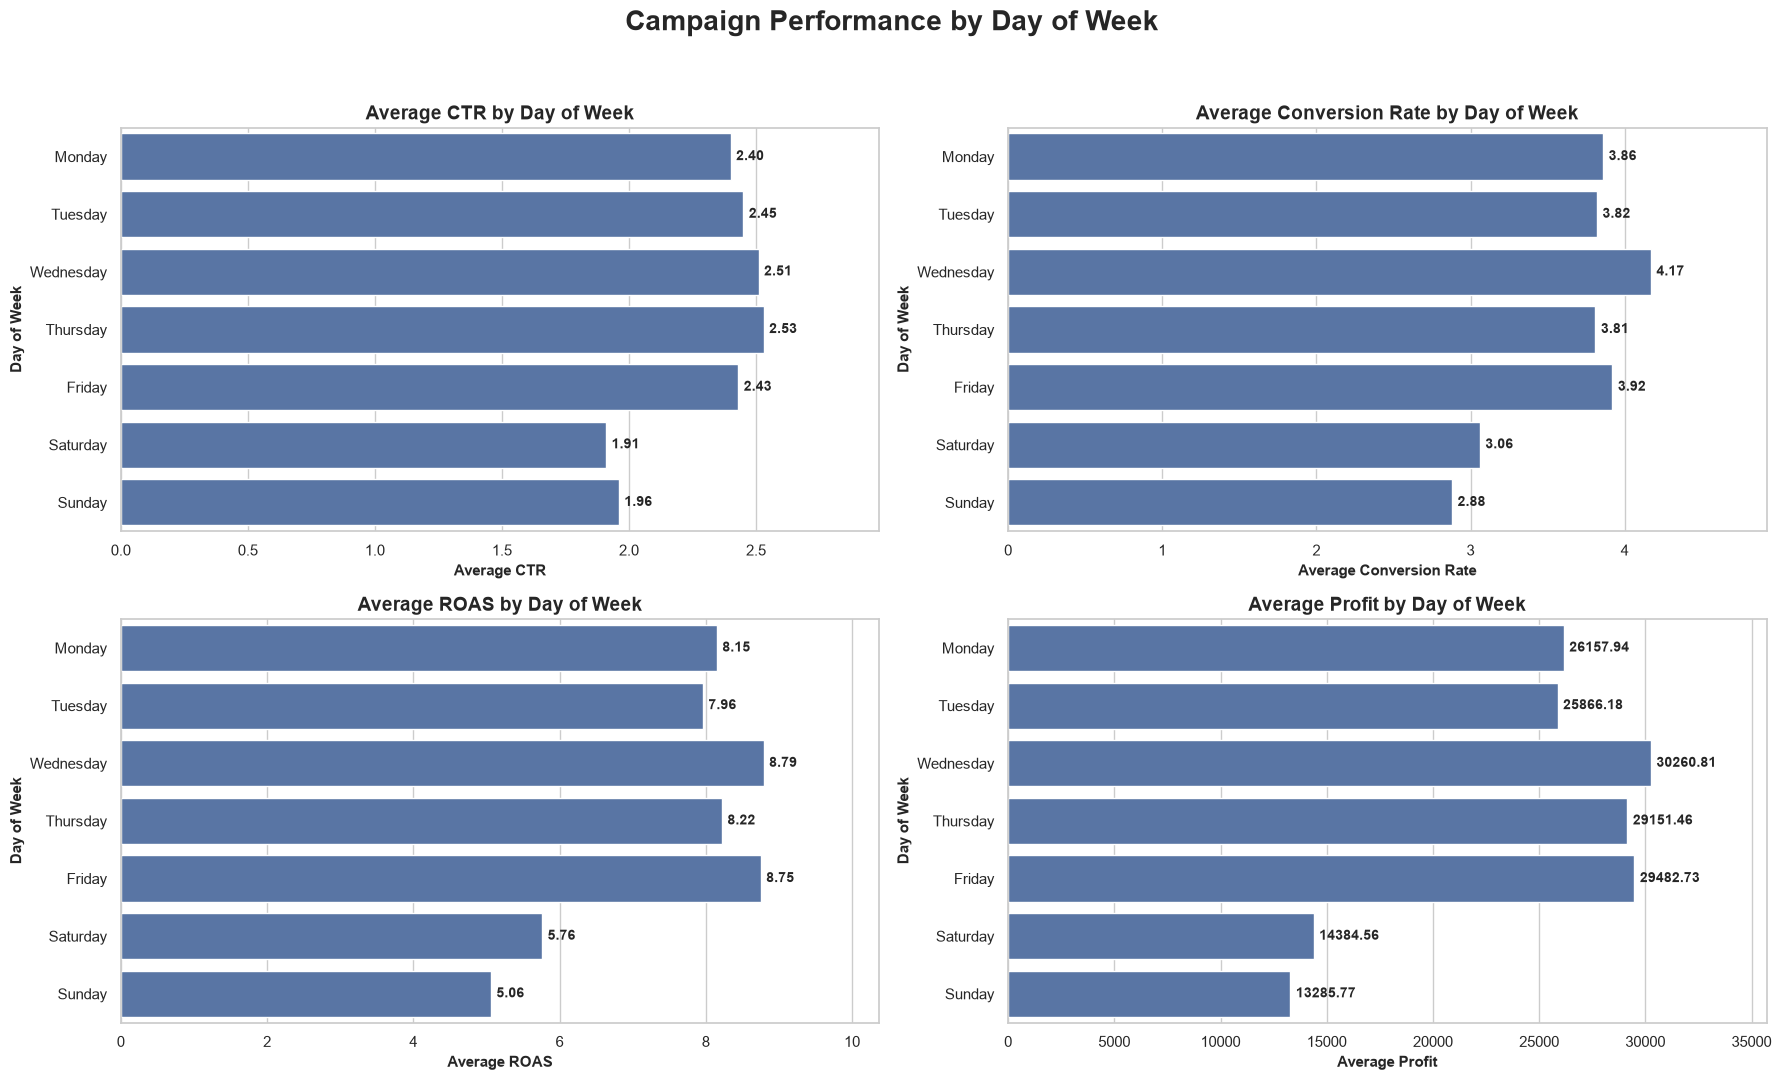

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index for visualization
day_plot = day_performance.reset_index()

# Define the correct order of days
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Apply day order
day_plot["day_of_week"] = pd.Categorical(
    day_plot["day_of_week"],
    categories=day_order,
    ordered=True
)

day_plot = day_plot.sort_values("day_of_week")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

fig.suptitle(
    "Campaign Performance by Day of Week",
    fontsize=20,
    fontweight="bold"
)

metrics = [
    ("Avg_CTR", "Average CTR by Day of Week", "Average CTR"),
    ("Avg_Conversion_Rate", "Average Conversion Rate by Day of Week", "Average Conversion Rate"),
    ("Avg_ROAS", "Average ROAS by Day of Week", "Average ROAS"),
    ("Avg_Profit", "Average Profit by Day of Week", "Average Profit")
]

# Create horizontal bar charts
for ax, (metric, title, xlabel) in zip(axes.flat, metrics):

    sns.barplot(
        data=day_plot,
        x=metric,
        y="day_of_week",
        order=day_order,
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11,fontweight="bold")
    ax.set_ylabel("Day of Week", fontsize=11,fontweight="bold")

    # Add exact values
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=4,
            fontsize=10,
            fontweight="bold"
        )

    # Add some space for labels
    max_value = day_plot[metric].max()
    ax.set_xlim(0, max_value * 1.18)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Correlation Analysis

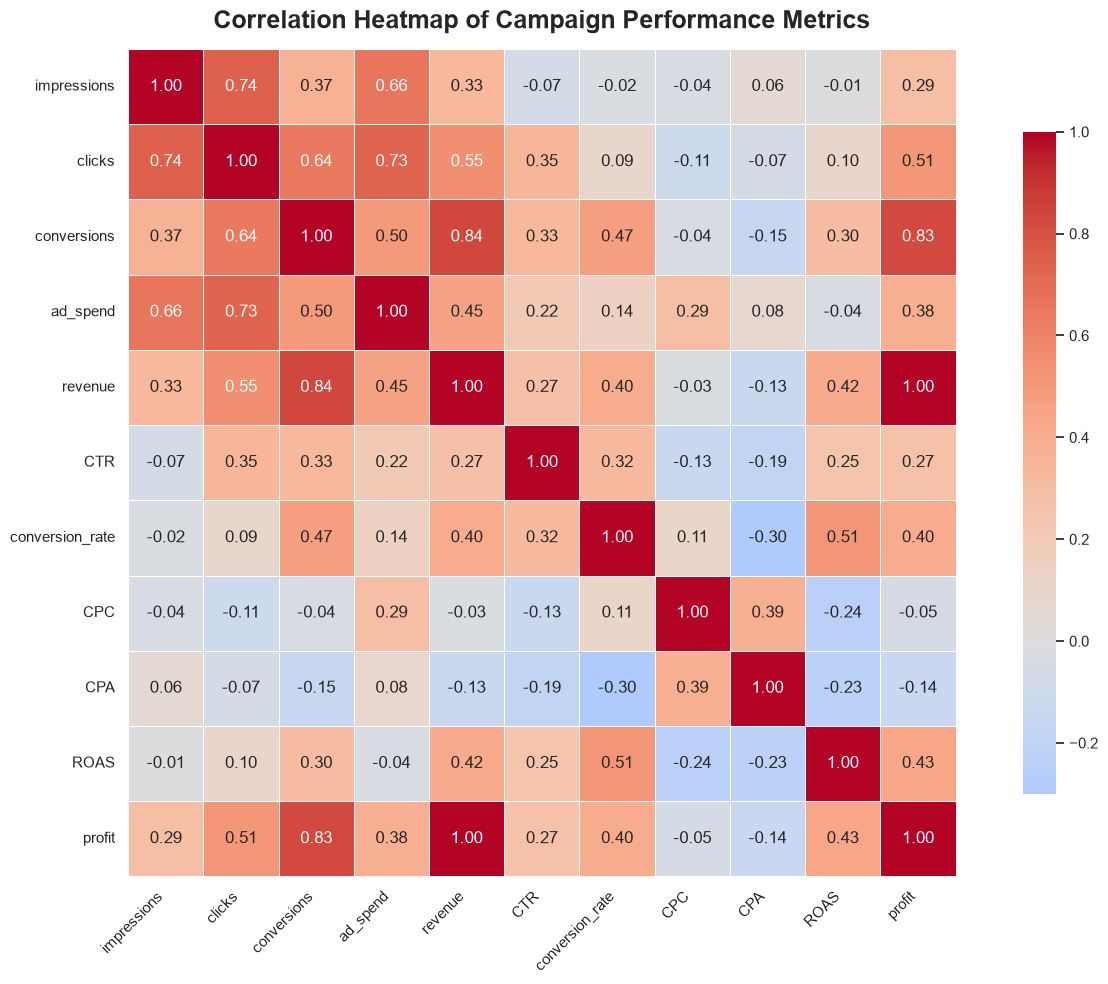

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical metrics for correlation analysis
correlation_columns = [
    "impressions",
    "clicks",
    "conversions",
    "ad_spend",
    "revenue",
    "CTR",
    "conversion_rate",
    "CPC",
    "CPA",
    "ROAS",
    "profit"
]

# Calculate correlation matrix
corr_matrix = df[correlation_columns].corr()

# Create heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Campaign Performance Metrics",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Relationship Analysis

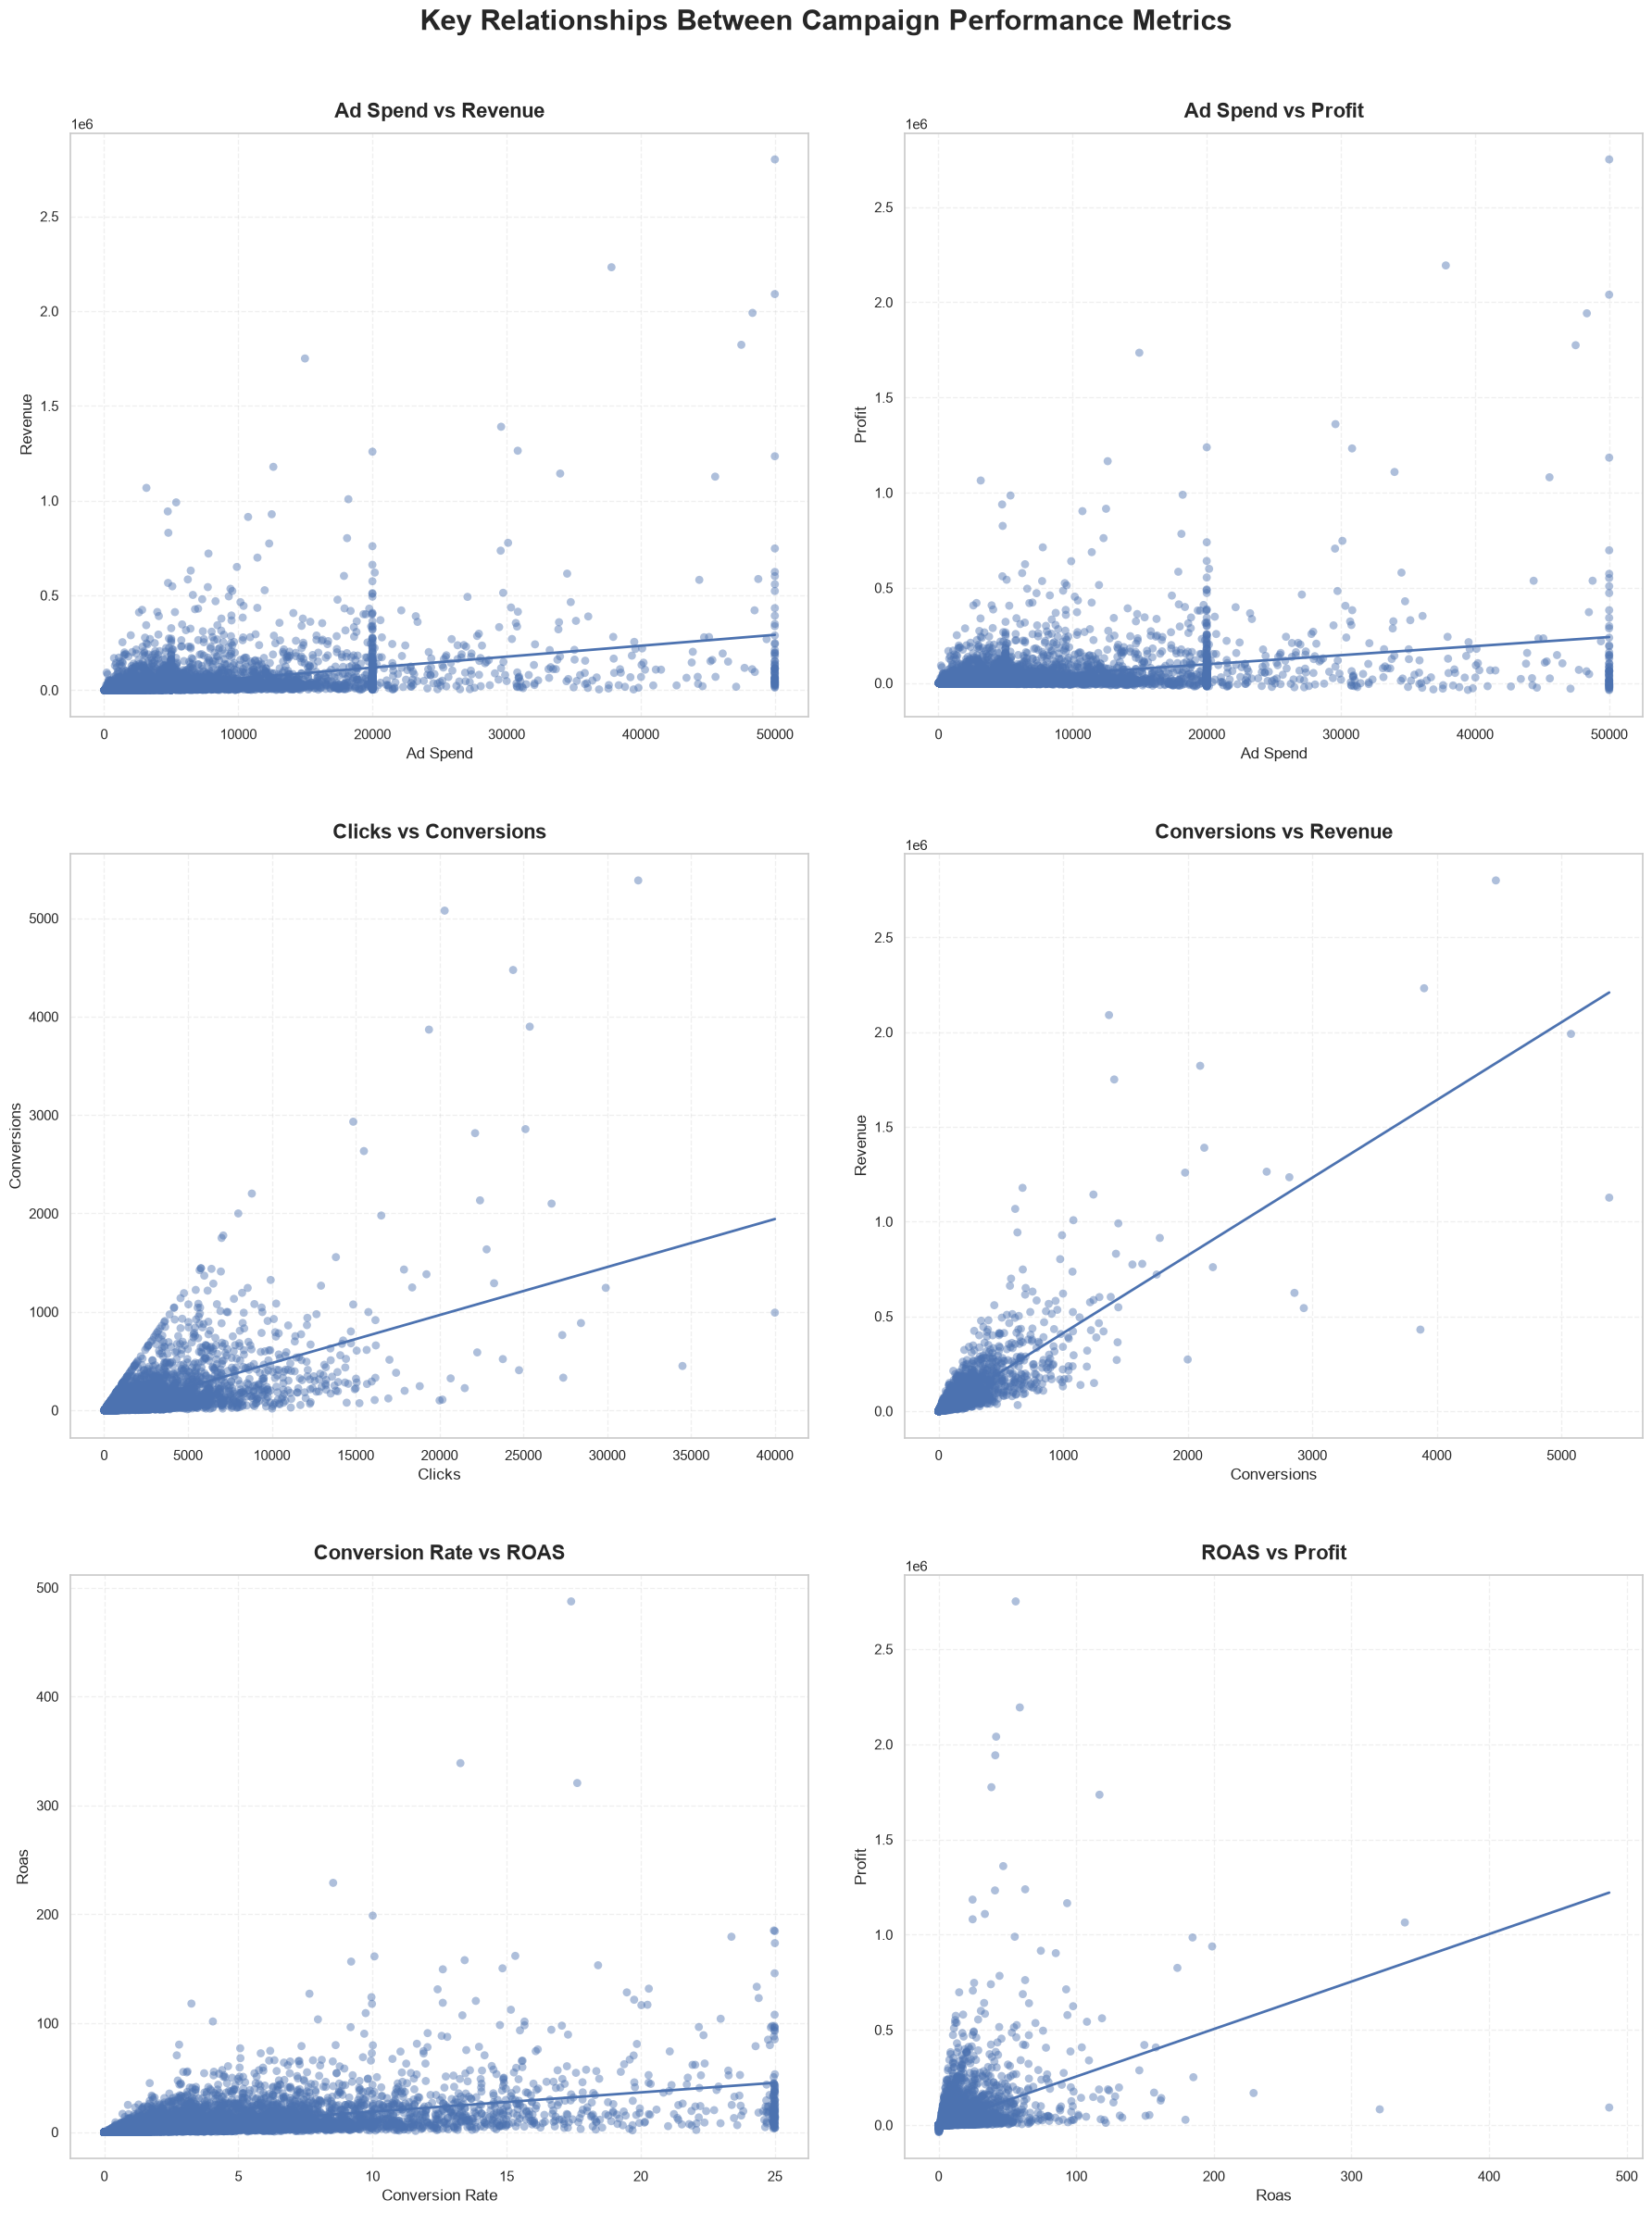

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3 rows × 2 columns layout
fig, axes = plt.subplots(3, 2, figsize=(18, 24))

fig.suptitle(
    "Key Relationships Between Campaign Performance Metrics",
    fontsize=22,
    fontweight="bold",
    y=0.995
)

relationships = [
    ("ad_spend", "revenue", "Ad Spend vs Revenue"),
    ("ad_spend", "profit", "Ad Spend vs Profit"),
    ("clicks", "conversions", "Clicks vs Conversions"),
    ("conversions", "revenue", "Conversions vs Revenue"),
    ("conversion_rate", "ROAS", "Conversion Rate vs ROAS"),
    ("ROAS", "profit", "ROAS vs Profit")
]

for ax, (x_col, y_col, title) in zip(axes.flat, relationships):

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        alpha=0.45,
        s=40,
        edgecolor="none",
        ax=ax
    )

    # Add regression trend line
    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter=False,
        ci=None,
        line_kws={"linewidth": 2},
        ax=ax
    )

    # Titles and labels
    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        x_col.replace("_", " ").title(),
        fontsize=12
    )

    ax.set_ylabel(
        y_col.replace("_", " ").title(),
        fontsize=12
    )

    # Improve readability
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout(
    rect=[0, 0, 1, 0.98],
    h_pad=4,
    w_pad=3
)

plt.show()

### EDA Insights and Business Findings

The exploratory data analysis revealed several important patterns in campaign performance, audience behavior, financial outcomes, and marketing efficiency.

#### 1. Data Distribution and Outliers

Several numerical variables, including **revenue, profit, CPA, ROAS, impressions, clicks, and conversions**, showed strong positive skewness and contained high-value outliers.

These outliers may represent genuinely high-performing or high-budget campaigns rather than data errors. Therefore, they were retained for further analysis. Their impact will be considered during the data preprocessing and modeling stages.

#### 2. Campaign Efficiency

The campaign efficiency metrics showed substantial variation across campaigns.

- **CTR** and **conversion rate** varied significantly, indicating differences in audience engagement and campaign effectiveness.
- **CPA** showed several high-value observations, suggesting that some campaigns were considerably more expensive in acquiring customers.
- **ROAS** contained extreme high values, indicating that a small number of campaigns generated exceptionally high returns.

#### 3. Platform Performance

Campaign performance differed across advertising platforms.

Some platforms demonstrated stronger performance in terms of **CTR, conversion rate, ROAS, and profit**, while others generated larger campaign volumes. This indicates that platform selection can significantly influence campaign outcomes.

#### 4. Campaign Objective Performance

Campaign objectives showed noticeable differences in performance.

**Conversion-focused campaigns** generally achieved stronger conversion rates, ROAS, and profitability compared to some awareness-oriented campaigns. This suggests that campaign objectives are strongly associated with the resulting performance metrics.

#### 5. Creative Format Performance

Creative format had a meaningful impact on campaign results.

**Video and Interactive formats** demonstrated relatively strong overall performance across engagement, conversion, ROAS, and profit metrics. In contrast, some formats showed lower average profitability.

This suggests that the choice of creative format can influence both campaign engagement and financial performance.

#### 6. Target Audience Performance

Campaign performance varied across different audience groups.

- Younger audience groups generally showed stronger **CTR and profit performance**.
- Conversion rates and ROAS varied across age groups.
- Gender-based analysis showed relatively smaller differences compared to age-based segmentation.

This indicates that audience targeting can play an important role in improving campaign effectiveness.

#### 7. Purchase Intent

Purchase intent showed one of the clearest performance patterns.

Campaigns targeting audiences with **High purchase intent** achieved substantially higher:

- Conversion rates
- ROAS
- Profit

CTR showed relatively smaller differences across intent levels. This suggests that purchase intent is particularly important for predicting conversion and financial outcomes.

#### 8. Industry Performance

Campaign performance differed considerably across industry verticals.

Certain industries achieved stronger **ROAS and profitability**, while others showed higher engagement or conversion performance. This indicates that industry-specific characteristics may influence advertising efficiency.

#### 9. Ad Placement Performance

Different ad placements produced varying levels of performance.

Some placements demonstrated stronger engagement, conversion rates, ROAS, and profitability. Therefore, ad placement may be an important feature for campaign optimization and predictive modeling.

#### 10. Time-Based Performance

Performance varied across different quarters and days of the week.

The quarterly analysis showed noticeable differences, with **Quarter 4 demonstrating particularly strong overall performance** across several key metrics.

Day-of-week analysis also revealed variations in engagement, conversion rates, ROAS, and profit, suggesting the presence of temporal patterns in campaign performance.

#### 11. Correlation Analysis

Several strong relationships were identified among the numerical variables.

- **Revenue and Profit** showed an extremely strong positive relationship.
- **Conversions and Revenue** showed a strong positive correlation.
- **Conversions and Profit** also demonstrated a strong positive relationship.
- **Impressions and Clicks** showed a strong positive correlation.
- **Clicks and Conversions** demonstrated a moderate-to-strong positive relationship.
- **Conversion Rate and ROAS** showed a moderate positive relationship.

These relationships indicate that campaign volume and conversion performance are strongly associated with financial outcomes.

#### 12. Overall Business Insight

The analysis suggests that campaign performance is influenced by a combination of factors, including:

- Advertising platform
- Campaign objective
- Creative format
- Target audience
- Purchase intent
- Industry vertical
- Ad placement
- Time-related factors

Among these factors, **purchase intent, conversions, campaign efficiency, and financial metrics** appear particularly important for understanding campaign success.

These findings will guide the next stages of the project, including **data preprocessing, feature engineering, and predictive modeling**.